# ĐỒ ÁN THỰC HÀNH KỸ THUẬT PHÂN TÍCH DỮ LIỆU  
# Credit Card Transaction Risk Analysis Dashboard — FINAL CODE V2

## 0. Định hướng bài toán

Dataset được phân công là dữ liệu giao dịch thẻ tín dụng. Tuy nhiên, dataset **không có nhãn gian lận thật** như `fraud`, `is_fraud`, `Class` hoặc `label`.

Vì vậy, notebook này không khẳng định phát hiện gian lận thật tuyệt đối. Hướng tiếp cận đúng là:

> Phân tích toàn bộ dataset theo các chiều có khả năng liên quan đến rủi ro giao dịch, sau đó xây dựng hệ thống `RiskScore` để nhận diện giao dịch cần theo dõi và giao dịch nghi ngờ cao.

Trong notebook:

- `NeedReview = 1` nếu `RiskScore >= 2`: giao dịch cần theo dõi.
- `PotentialFraud = 1` nếu `RiskScore >= 3`: giao dịch nghi ngờ cao.
- `PotentialFraud` là **nhãn proxy**, không phải nhãn gian lận thật từ ngân hàng.

## Mạch xử lý

```text
Dữ liệu gốc
→ Kiểm tra dữ liệu
→ Merge dữ liệu
→ Feature Engineering
→ EDA trước RiskScore
→ Phân tích tỷ lệ giao dịch so với hạn mức
→ Xây dựng RiskScore điều chỉnh theo phân phối dữ liệu
→ EDA sau RiskScore
→ ANOVA
→ Chi-square
→ Linear Regression
→ Feature Audit
→ Logistic Regression
→ Decision Tree
→ So sánh mô hình
→ Xuất dữ liệu cho Dashboard và Slide
```

# 1. Import thư viện và cấu hình

Phần này import các thư viện cần thiết cho:

- Xử lý dữ liệu: `pandas`, `numpy`
- Trực quan hóa: `matplotlib`
- Kiểm định thống kê: `scipy`, `statsmodels`
- Machine Learning: `scikit-learn`
- Xuất file: `pathlib`, `zipfile`, `json`

Notebook được viết theo hướng dễ chạy trên Colab/Jupyter.

In [3]:
import os
import json
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import levene, f_oneway, chi2_contingency
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Nếu chạy Colab, upload file zip vào session hoặc sửa đường dẫn dưới đây.
DATA_ZIP_PATH = Path("9-CreditCard-Fraud-Detection.zip")

DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = Path("outputs")
FIG_DIR = OUTPUT_DIR / "figures"
DASHBOARD_DIR = OUTPUT_DIR / "dashboard_inputs"

for folder in [RAW_DIR, PROCESSED_DIR, OUTPUT_DIR, FIG_DIR, DASHBOARD_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Working directory:", Path.cwd())
print("Output directory:", OUTPUT_DIR.resolve())

Working directory: /content
Output directory: /content/outputs


# 2. Đọc dữ liệu gốc

Dataset gồm 2 file chính:

- `cc_info.csv`: thông tin thẻ, thành phố, tiểu bang, zipcode, hạn mức.
- `transactions.csv`: thông tin giao dịch, thời gian, số tiền, tọa độ.

Nếu file đang ở dạng `.zip`, notebook sẽ tự giải nén.

In [4]:
def unzip_if_needed(zip_path: Path, extract_dir: Path):
    """Giải nén file zip nếu tồn tại."""
    if zip_path.exists():
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(extract_dir)
        print(f"Đã giải nén: {zip_path} → {extract_dir}")
    else:
        print(f"Không tìm thấy file zip: {zip_path}")
        print("Nếu đã giải nén sẵn, hãy đặt cc_info.csv và transactions.csv trong thư mục data/raw/.")

unzip_if_needed(DATA_ZIP_PATH, RAW_DIR)

csv_files = list(RAW_DIR.rglob("*.csv"))
print("Các file CSV tìm thấy:")
for f in csv_files:
    print("-", f)

def find_csv(keyword):
    matches = [f for f in csv_files if keyword.lower() in f.name.lower()]
    if not matches:
        raise FileNotFoundError(f"Không tìm thấy file chứa keyword: {keyword}")
    return matches[0]

cc_info_path = find_csv("cc_info")
transactions_path = find_csv("transactions")

cc_info = pd.read_csv(cc_info_path)
transactions = pd.read_csv(transactions_path)

print("cc_info shape:", cc_info.shape)
display(cc_info.head())

print("transactions shape:", transactions.shape)
display(transactions.head())

Đã giải nén: 9-CreditCard-Fraud-Detection.zip → data/raw
Các file CSV tìm thấy:
- data/raw/cc_info.csv
- data/raw/transactions.csv
cc_info shape: (984, 5)


,credit_card,city,state,zipcode,credit_card_limit
0,1280981422329509,Dallas,PA,18612,6000
1,9737219864179988,Houston,PA,15342,16000
2,4749889059323202,Auburn,MA,1501,14000
3,9591503562024072,Orlando,WV,26412,18000
4,2095640259001271,New York,NY,10001,20000


transactions shape: (294588, 5)


,credit_card,date,transaction_dollar_amount,Long,Lat
0,1003715054175576,2015-09-11 00:32:40,43.7800,-80.1741,40.2674
1,1003715054175576,2015-10-24 22:23:08,103.1500,-80.1942,40.1801
2,1003715054175576,2015-10-26 18:19:36,48.5500,-80.2110,40.3130
3,1003715054175576,2015-10-22 19:41:10,136.1800,-80.1741,40.2909
4,1003715054175576,2015-10-26 20:08:22,71.8200,-80.2387,40.1667


# 3. Kiểm tra dữ liệu ban đầu

Trước khi xử lý, cần kiểm tra:

- Shape
- Kiểu dữ liệu
- Missing values
- Duplicates
- Số lượng giá trị khác nhau của từng cột

Đây là bước bắt buộc để tránh hiểu sai dataset.

In [5]:
def basic_profile(df, name):
    """Tạo bảng profile cơ bản cho DataFrame."""
    profile = pd.DataFrame({
        "column": df.columns,
        "dtype": [df[c].dtype for c in df.columns],
        "missing_count": [df[c].isna().sum() for c in df.columns],
        "missing_pct": [df[c].isna().mean() * 100 for c in df.columns],
        "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
    })

    print("=" * 80)
    print(f"PROFILE: {name}")
    print("Shape:", df.shape)
    print("Duplicated rows:", df.duplicated().sum())
    display(profile)
    return profile

cc_profile = basic_profile(cc_info, "cc_info")
txn_profile = basic_profile(transactions, "transactions")

cc_profile.to_csv(OUTPUT_DIR / "profile_cc_info.csv", index=False, encoding="utf-8-sig")
txn_profile.to_csv(OUTPUT_DIR / "profile_transactions.csv", index=False, encoding="utf-8-sig")

PROFILE: cc_info
Shape: (984, 5)
Duplicated rows: 0


,column,dtype,missing_count,missing_pct,n_unique
0,credit_card,int64,0,0.0000,984
1,city,object,0,0.0000,124
2,state,object,0,0.0000,35
3,zipcode,int64,0,0.0000,124
4,credit_card_limit,int64,0,0.0000,28


PROFILE: transactions
Shape: (294588, 5)
Duplicated rows: 0


,column,dtype,missing_count,missing_pct,n_unique
0,credit_card,int64,0,0.0000,984
1,date,object,0,0.0000,281065
2,transaction_dollar_amount,float64,0,0.0000,30196
3,Long,float64,0,0.0000,294588
4,Lat,float64,0,0.0000,294588


## Nhận xét phần kiểm tra dữ liệu

Sau khi chạy cell trên, cần ghi nhận:

- Dataset có bao nhiêu dòng/cột.
- Có thiếu dữ liệu không.
- Có dòng trùng lặp không.
- Cột `date` cần chuyển sang datetime.
- `zipcode` tuy nhìn giống số nhưng bản chất là mã khu vực, không phải biến định lượng.

# 4. Phân loại biến gốc

Mục tiêu của phần này là “chẻ dataset” ngay từ đầu.

Các nhóm biến gốc:

| Nhóm biến | Biến |
|---|---|
| Định danh | `credit_card` |
| Thời gian | `date` |
| Định lượng | `transaction_dollar_amount`, `credit_card_limit`, `Long`, `Lat` |
| Phân loại | `city`, `state`, `zipcode` |

In [6]:
raw_variable_groups = pd.DataFrame([
    ["Định danh", "credit_card", "Mã thẻ, dùng để nhóm lịch sử giao dịch theo từng thẻ"],
    ["Thời gian", "date", "Thời điểm phát sinh giao dịch"],
    ["Định lượng", "transaction_dollar_amount", "Số tiền giao dịch"],
    ["Định lượng", "credit_card_limit", "Hạn mức tín dụng"],
    ["Định lượng", "Long", "Kinh độ giao dịch"],
    ["Định lượng", "Lat", "Vĩ độ giao dịch"],
    ["Phân loại", "city", "Thành phố"],
    ["Phân loại", "state", "Tiểu bang/khu vực"],
    ["Phân loại", "zipcode", "Mã bưu chính, bản chất là biến khu vực"],
], columns=["nhom_bien", "bien", "y_nghia"])

display(raw_variable_groups)
raw_variable_groups.to_csv(OUTPUT_DIR / "raw_variable_groups.csv", index=False, encoding="utf-8-sig")

,nhom_bien,bien,y_nghia
0,Định danh,credit_card,"Mã thẻ, dùng để nhóm lịch sử giao dịch theo từ..."
1,Thời gian,date,Thời điểm phát sinh giao dịch
2,Định lượng,transaction_dollar_amount,Số tiền giao dịch
3,Định lượng,credit_card_limit,Hạn mức tín dụng
4,Định lượng,Long,Kinh độ giao dịch
5,Định lượng,Lat,Vĩ độ giao dịch
6,Phân loại,city,Thành phố
7,Phân loại,state,Tiểu bang/khu vực
8,Phân loại,zipcode,"Mã bưu chính, bản chất là biến khu vực"


## Nhận xét phần phân loại biến

Dataset ban đầu tuy không có nhiều cột, nhưng có thể khai thác theo nhiều hướng:

- `date` → phân tích thời gian.
- `transaction_dollar_amount` và `credit_card_limit` → phân tích số tiền và hạn mức.
- `credit_card` → phân tích lịch sử từng thẻ.
- `Lat`, `Long`, `city`, `state`, `zipcode` → phân tích địa lý.

# 5. Tiền xử lý cơ bản và merge dữ liệu

Phần này chỉ làm tiền xử lý cơ bản để dữ liệu đủ sạch cho EDA:

1. Chuẩn hóa tên cột.
2. Chuyển `date` sang datetime.
3. Merge `transactions` và `cc_info` theo `credit_card`.
4. Sắp xếp theo `credit_card`, `date`.
5. Kiểm tra missing/duplicates sau merge.

In [7]:
cc_info.columns = cc_info.columns.str.strip()
transactions.columns = transactions.columns.str.strip()

required_cc = ["credit_card", "city", "state", "zipcode", "credit_card_limit"]
required_txn = ["credit_card", "date", "transaction_dollar_amount", "Long", "Lat"]

missing_cc = [c for c in required_cc if c not in cc_info.columns]
missing_txn = [c for c in required_txn if c not in transactions.columns]

if missing_cc:
    raise ValueError(f"cc_info thiếu cột: {missing_cc}")
if missing_txn:
    raise ValueError(f"transactions thiếu cột: {missing_txn}")

transactions["date"] = pd.to_datetime(transactions["date"], errors="coerce")
print("Số dòng date parse lỗi:", transactions["date"].isna().sum())

df = transactions.merge(cc_info, on="credit_card", how="left", validate="many_to_one")
df = df.sort_values(["credit_card", "date"]).reset_index(drop=True)

print("Shape sau merge:", df.shape)
print("Duplicated sau merge:", df.duplicated().sum())
display(df.isna().sum().sort_values(ascending=False).head(20))
display(df.head())

df.to_csv(PROCESSED_DIR / "creditcard_merged_basic.csv", index=False, encoding="utf-8-sig")

Số dòng date parse lỗi: 0
Shape sau merge: (294588, 9)
Duplicated sau merge: 0


,0
credit_card,0
date,0
transaction_dollar_amount,0
Long,0
Lat,0
city,0
state,0
zipcode,0
credit_card_limit,0


,credit_card,date,transaction_dollar_amount,Long,Lat,city,state,zipcode,credit_card_limit
0,1003715054175576,2015-07-31 20:03:05,45.5200,-80.1863,40.1684,Houston,PA,15342,20000
1,1003715054175576,2015-07-31 20:25:28,96.1000,-80.1561,40.2229,Houston,PA,15342,20000
2,1003715054175576,2015-07-31 23:09:32,20.9400,-80.2622,40.2425,Houston,PA,15342,20000
3,1003715054175576,2015-08-01 10:48:03,51.2700,-80.1769,40.3133,Houston,PA,15342,20000
4,1003715054175576,2015-08-01 17:43:43,127.9900,-80.2267,40.2960,Houston,PA,15342,20000


## Nhận xét sau merge

Sau merge, mỗi dòng là một giao dịch đã có đủ:

- Thời gian giao dịch
- Số tiền giao dịch
- Tọa độ
- Thông tin thành phố/tiểu bang/zipcode
- Hạn mức thẻ

Từ đây có thể bắt đầu Feature Engineering và EDA.

# 6. Feature Engineering

Feature Engineering giúp khai thác thêm ý nghĩa từ biến gốc.

Notebook tạo 4 nhóm đặc trưng:

1. Đặc trưng thời gian.
2. Đặc trưng hạn mức.
3. Đặc trưng lịch sử theo từng thẻ.
4. Đặc trưng địa lý.

Nguyên tắc:

> Tạo biến mới phải có lý do phân tích rõ ràng, không tạo cho nhiều.

## 6.1. Đặc trưng thời gian

Tạo từ `date`:

- `hour`
- `dayofweek`
- `month_num`
- `year_month`
- `is_weekend`
- `is_night`
- `time_group`

Dùng cho EDA, Chi-square, RiskScore và dashboard.

In [8]:
df["hour"] = df["date"].dt.hour
df["dayofweek"] = df["date"].dt.dayofweek
df["month_num"] = df["date"].dt.month
df["year_month"] = df["date"].dt.to_period("M").astype(str)
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

# Ban đêm được định nghĩa là 23h đến 5h.
df["is_night"] = ((df["hour"] >= 23) | (df["hour"] <= 5)).astype(int)

def assign_time_group(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 23:
        return "Evening"
    else:
        return "Night"

df["time_group"] = df["hour"].apply(assign_time_group)

display(df[["date", "hour", "dayofweek", "month_num", "year_month", "is_weekend", "is_night", "time_group"]].head())
display(df["time_group"].value_counts())

,date,hour,dayofweek,month_num,year_month,is_weekend,is_night,time_group
0,2015-07-31 20:03:05,20,4,7,2015-07,0,0,Evening
1,2015-07-31 20:25:28,20,4,7,2015-07,0,0,Evening
2,2015-07-31 23:09:32,23,4,7,2015-07,0,1,Night
3,2015-08-01 10:48:03,10,5,8,2015-08,1,0,Morning
4,2015-08-01 17:43:43,17,5,8,2015-08,1,0,Evening


,count
time_group,
Evening,192635
Night,73838
Afternoon,26593
Morning,1522


## 6.2. Đặc trưng hạn mức

Tạo từ `transaction_dollar_amount` và `credit_card_limit`:

- `limit_group`
- `amount_to_limit`
- `daily_cum_amount`
- `daily_cum_to_limit`
- `daily_txn_count`

Ý nghĩa:

> Cùng một số tiền giao dịch có thể bình thường với thẻ hạn mức cao nhưng bất thường với thẻ hạn mức thấp.

In [9]:
# Chia hạn mức thành 4 nhóm theo quantile.
limit_code = pd.qcut(df["credit_card_limit"], q=4, labels=False, duplicates="drop")
limit_map = {0: "Low", 1: "Medium", 2: "High", 3: "Very High"}
df["limit_group"] = limit_code.map(limit_map).astype(str)

# Tỷ lệ số tiền giao dịch trên hạn mức.
df["amount_to_limit"] = df["transaction_dollar_amount"] / df["credit_card_limit"].replace(0, np.nan)
df["amount_to_limit"] = df["amount_to_limit"].replace([np.inf, -np.inf], np.nan).fillna(0)

# Tổng tiền và số giao dịch trong ngày của từng thẻ.
df["txn_date"] = df["date"].dt.date
df["daily_cum_amount"] = df.groupby(["credit_card", "txn_date"])["transaction_dollar_amount"].cumsum()
df["daily_txn_count"] = df.groupby(["credit_card", "txn_date"]).cumcount() + 1

df["daily_cum_to_limit"] = df["daily_cum_amount"] / df["credit_card_limit"].replace(0, np.nan)
df["daily_cum_to_limit"] = df["daily_cum_to_limit"].replace([np.inf, -np.inf], np.nan).fillna(0)

display(df[[
    "credit_card", "date", "transaction_dollar_amount", "credit_card_limit",
    "limit_group", "amount_to_limit", "daily_cum_amount",
    "daily_cum_to_limit", "daily_txn_count"
]].head(10))

display(df["limit_group"].value_counts())

,credit_card,date,transaction_dollar_amount,credit_card_limit,limit_group,amount_to_limit,daily_cum_amount,daily_cum_to_limit,daily_txn_count
0,1003715054175576,2015-07-31 20:03:05,45.5200,20000,High,0.0023,45.5200,0.0023,1
1,1003715054175576,2015-07-31 20:25:28,96.1000,20000,High,0.0048,141.6200,0.0071,2
2,1003715054175576,2015-07-31 23:09:32,20.9400,20000,High,0.0010,162.5600,0.0081,3
3,1003715054175576,2015-08-01 10:48:03,51.2700,20000,High,0.0026,51.2700,0.0026,1
4,1003715054175576,2015-08-01 17:43:43,127.9900,20000,High,0.0064,179.2600,0.0090,2
5,1003715054175576,2015-08-01 17:44:19,96.9700,20000,High,0.0048,276.2300,0.0138,3
6,1003715054175576,2015-08-01 19:10:09,97.3500,20000,High,0.0049,373.5800,0.0187,4
7,1003715054175576,2015-08-02 19:39:29,131.4300,20000,High,0.0066,131.4300,0.0066,1
8,1003715054175576,2015-08-02 22:40:59,85.7400,20000,High,0.0043,217.1700,0.0109,2
9,1003715054175576,2015-08-03 00:27:43,80.6700,20000,High,0.0040,80.6700,0.0040,1


,count
limit_group,
Low,106158
High,80210
Medium,57800
Very High,50420


## 6.3. Đặc trưng lịch sử theo từng thẻ

Tạo các biến để so sánh giao dịch hiện tại với hành vi trước đó của chính thẻ:

- `prev_amount_mean`
- `prev_amount_std`
- `amount_zscore_prev`
- `minutes_since_prev_txn`
- `minutes_since_prev_txn_capped`
- `prev_txn_count`

Lưu ý:

> Các biến lịch sử được tính từ các giao dịch trước đó để hạn chế dùng thông tin tương lai.

In [10]:
g = df.groupby("credit_card")["transaction_dollar_amount"]

# Dùng shift(1) để chỉ lấy lịch sử trước giao dịch hiện tại.
df["prev_amount_mean"] = g.transform(lambda s: s.shift(1).expanding(min_periods=2).mean())
df["prev_amount_std"] = g.transform(lambda s: s.shift(1).expanding(min_periods=2).std())

global_mean = df["transaction_dollar_amount"].mean()
global_std = df["transaction_dollar_amount"].std()

df["prev_amount_mean"] = df["prev_amount_mean"].fillna(global_mean)
df["prev_amount_std"] = df["prev_amount_std"].fillna(global_std).replace(0, global_std)

df["amount_zscore_prev"] = (
    (df["transaction_dollar_amount"] - df["prev_amount_mean"]) / df["prev_amount_std"]
)

df["prev_txn_time"] = df.groupby("credit_card")["date"].shift(1)
df["minutes_since_prev_txn"] = (df["date"] - df["prev_txn_time"]).dt.total_seconds() / 60

# Giao dịch đầu tiên của thẻ không có giao dịch trước, nên gán giá trị rất lớn.
df["minutes_since_prev_txn"] = df["minutes_since_prev_txn"].fillna(999999)

# Bản capped dùng cho ANOVA để tránh giao dịch đầu tiên làm méo phân phối.
df["minutes_since_prev_txn_capped"] = df["minutes_since_prev_txn"].clip(upper=24 * 60)

def count_prev_txn_within_window(group, window_minutes=30):
    """Đếm số giao dịch trước đó trong vòng window_minutes của cùng thẻ."""
    times = group["date"].values.astype("datetime64[ns]")
    counts = np.zeros(len(group), dtype=int)
    start = 0

    for i in range(len(group)):
        while start < i and (times[i] - times[start]) / np.timedelta64(1, "m") > window_minutes:
            start += 1
        counts[i] = i - start

    return pd.Series(counts, index=group.index)

df["prev_txn_count"] = (
    df.groupby("credit_card", group_keys=False)
      .apply(count_prev_txn_within_window)
)

display(df[[
    "credit_card", "date", "transaction_dollar_amount",
    "prev_amount_mean", "prev_amount_std", "amount_zscore_prev",
    "minutes_since_prev_txn", "minutes_since_prev_txn_capped", "prev_txn_count"
]].head(12))

,credit_card,date,transaction_dollar_amount,prev_amount_mean,prev_amount_std,amount_zscore_prev,minutes_since_prev_txn,minutes_since_prev_txn_capped,prev_txn_count
0,1003715054175576,2015-07-31 20:03:05,45.5200,86.0080,124.6560,-0.3248,"999,999.0000","1,440.0000",0
1,1003715054175576,2015-07-31 20:25:28,96.1000,86.0080,124.6560,0.0810,22.3833,22.3833,1
2,1003715054175576,2015-07-31 23:09:32,20.9400,70.8100,35.7655,-1.3944,164.0667,164.0667,0
3,1003715054175576,2015-08-01 10:48:03,51.2700,54.1867,38.3222,-0.0761,698.5167,698.5167,0
4,1003715054175576,2015-08-01 17:43:43,127.9900,53.4575,31.3239,2.3794,415.6667,415.6667,0
5,1003715054175576,2015-08-01 17:44:19,96.9700,68.3640,42.9757,0.6656,0.6000,0.6000,1
6,1003715054175576,2015-08-01 19:10:09,97.3500,73.1317,40.1735,0.6028,85.8333,85.8333,0
7,1003715054175576,2015-08-02 19:39:29,131.4300,76.5914,37.7984,1.4508,"1,469.3333","1,440.0000",0
8,1003715054175576,2015-08-02 22:40:59,85.7400,83.4462,40.0065,0.0573,181.5000,181.5000,0
9,1003715054175576,2015-08-03 00:27:43,80.6700,83.7011,37.4305,-0.0810,106.7333,106.7333,0


## 6.4. Đặc trưng địa lý

Tạo:

- `state_full_name`
- `distance_from_card_center_km`
- `distance_group`

`distance_from_card_center_km` đo khoảng cách giữa giao dịch hiện tại và vùng giao dịch trung tâm của từng thẻ.

Lưu ý quan trọng:

> Biến địa lý là tín hiệu bổ trợ. Giao dịch xa vùng quen thuộc không đồng nghĩa gian lận vì chủ thẻ có thể đi du lịch/công tác.

In [11]:
STATE_ABBR_TO_NAME = {
    "AL":"Alabama","AK":"Alaska","AZ":"Arizona","AR":"Arkansas","CA":"California",
    "CO":"Colorado","CT":"Connecticut","DE":"Delaware","DC":"District of Columbia",
    "FL":"Florida","GA":"Georgia","HI":"Hawaii","ID":"Idaho","IL":"Illinois",
    "IN":"Indiana","IA":"Iowa","KS":"Kansas","KY":"Kentucky","LA":"Louisiana",
    "ME":"Maine","MD":"Maryland","MA":"Massachusetts","MI":"Michigan","MN":"Minnesota",
    "MS":"Mississippi","MO":"Missouri","MT":"Montana","NE":"Nebraska","NV":"Nevada",
    "NH":"New Hampshire","NJ":"New Jersey","NM":"New Mexico","NY":"New York",
    "NC":"North Carolina","ND":"North Dakota","OH":"Ohio","OK":"Oklahoma",
    "OR":"Oregon","PA":"Pennsylvania","RI":"Rhode Island","SC":"South Carolina",
    "SD":"South Dakota","TN":"Tennessee","TX":"Texas","UT":"Utah","VT":"Vermont",
    "VA":"Virginia","WA":"Washington","WV":"West Virginia","WI":"Wisconsin","WY":"Wyoming"
}

df["state"] = df["state"].astype(str)
df["state_full_name"] = df["state"].map(STATE_ABBR_TO_NAME).fillna(df["state"])

def haversine_km(lat1, lon1, lat2, lon2):
    """Tính khoảng cách địa lý giữa hai điểm tọa độ bằng công thức Haversine."""
    R = 6371
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))

# Trung tâm giao dịch của thẻ: dùng cho EDA/dashboard, không đưa vào model chính.
card_center = df.groupby("credit_card").agg(
    card_center_lat=("Lat", "mean"),
    card_center_long=("Long", "mean")
).reset_index()

df = df.merge(card_center, on="credit_card", how="left")

df["distance_from_card_center_km"] = haversine_km(
    df["Lat"], df["Long"],
    df["card_center_lat"], df["card_center_long"]
)

distance_code = pd.qcut(df["distance_from_card_center_km"], q=4, labels=False, duplicates="drop")
distance_map = {0: "Near", 1: "Medium", 2: "Far", 3: "Very Far"}
df["distance_group"] = distance_code.map(distance_map).astype(str)

display(df[[
    "credit_card", "state", "state_full_name", "Lat", "Long",
    "distance_from_card_center_km", "distance_group"
]].head())

display(df["distance_group"].value_counts())

,credit_card,state,state_full_name,Lat,Long,distance_from_card_center_km,distance_group
0,1003715054175576,PA,Pennsylvania,40.1684,-80.1863,230.5400,Very Far
1,1003715054175576,PA,Pennsylvania,40.2229,-80.1561,229.6989,Very Far
2,1003715054175576,PA,Pennsylvania,40.2425,-80.2622,238.9548,Very Far
3,1003715054175576,PA,Pennsylvania,40.3133,-80.1769,234.4087,Very Far
4,1003715054175576,PA,Pennsylvania,40.2960,-80.2267,237.8139,Very Far


,count
distance_group,
Very Far,73647
Far,73647
Medium,73647
Near,73647


## Nhận xét sau Feature Engineering

Sau Feature Engineering, dataset đã được khai thác sâu hơn:

- Thời gian: giờ, tháng, cuối tuần, ban đêm, khung giờ.
- Hạn mức: nhóm hạn mức, tỷ lệ amount/limit, tổng ngày/limit.
- Lịch sử thẻ: z-score theo lịch sử, thời gian từ giao dịch trước, số giao dịch gần.
- Địa lý: khoảng cách so với vùng giao dịch trung tâm.

Điểm quan trọng:

> Các biến mới không tạo tùy tiện. Mỗi biến phục vụ một câu hỏi phân tích hoặc một phần trong RiskScore/dashboard.

# 7. EDA trước RiskScore

EDA trước RiskScore nhằm hiểu dataset trước khi tạo nhãn proxy.

Các câu hỏi chính:

1. Số tiền giao dịch phân phối như thế nào?
2. Giao dịch tập trung vào giờ/tháng nào?
3. Nhóm hạn mức có hành vi giao dịch khác nhau không?
4. Các biến định lượng có tương quan với nhau không?

,metric,value
0,total_transactions,294588
1,total_credit_cards,984
2,total_states,35
3,total_cities,124
4,date_min,2015-07-31 09:39:48
5,date_max,2015-10-30 10:54:58
6,total_amount,"25,336,935.3600"
7,mean_amount,86.0080
8,median_amount,58.4700
9,std_amount,124.6560


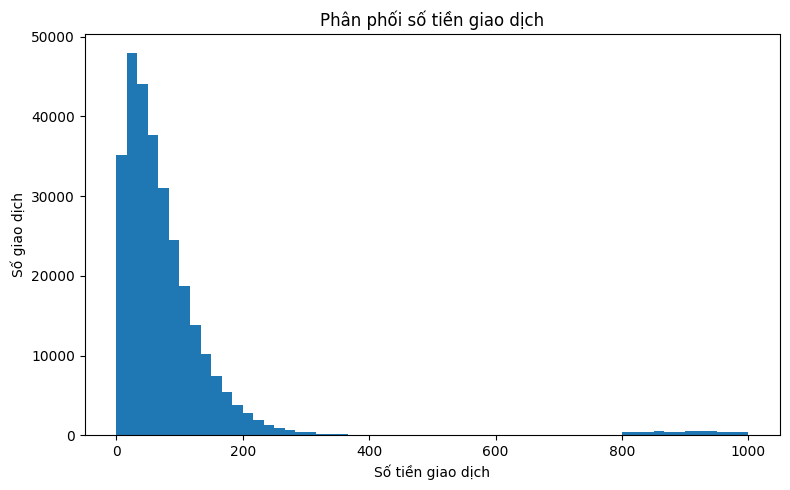

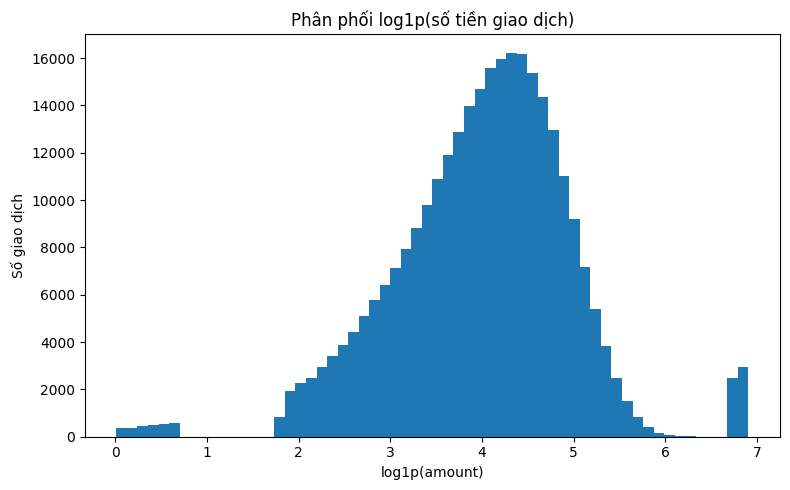

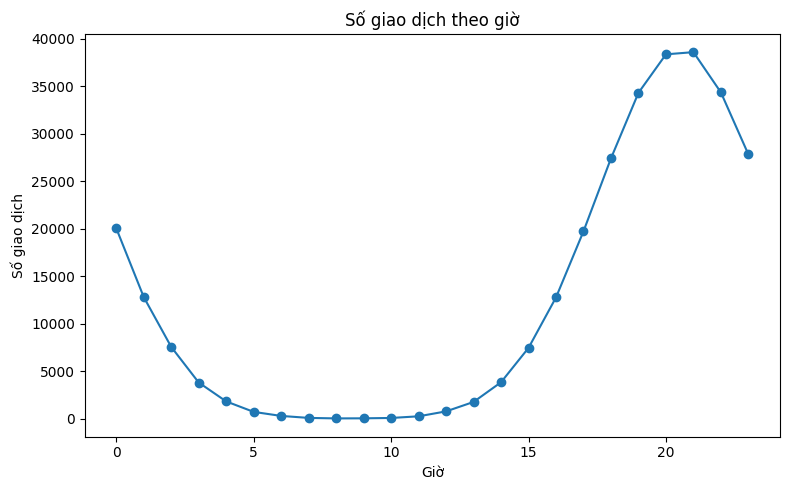

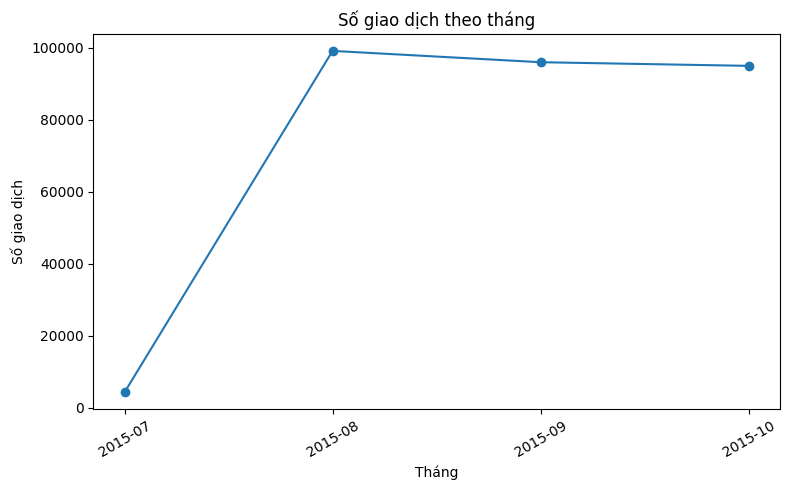

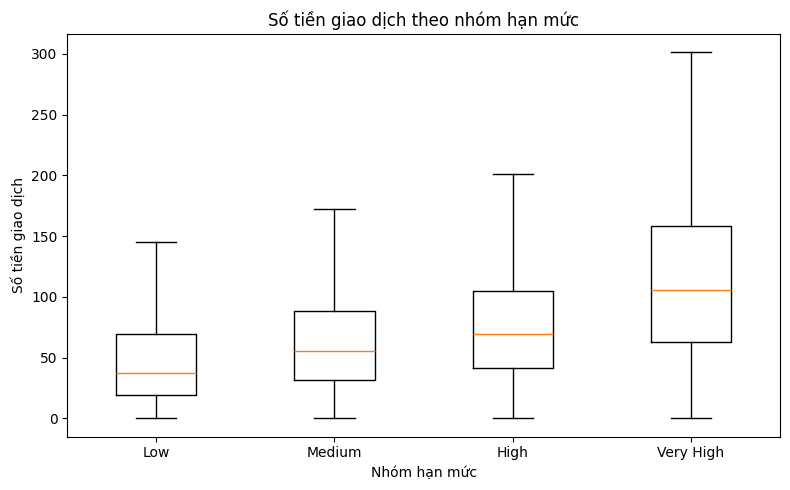

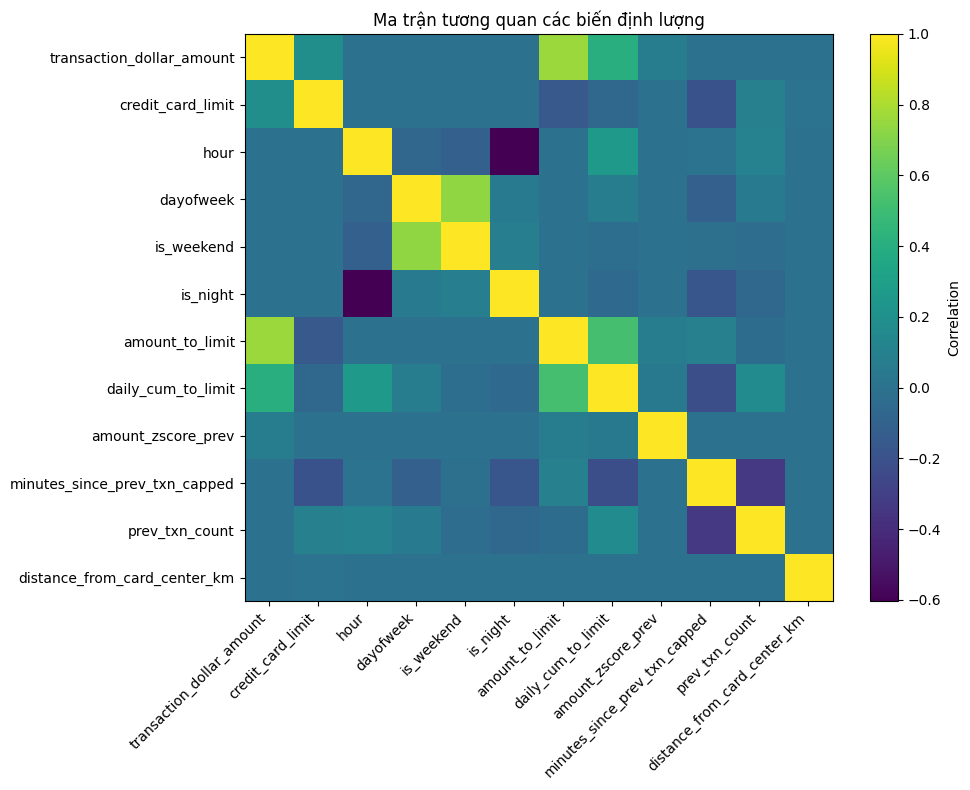

In [12]:
def save_fig(filename):
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

eda_summary = pd.DataFrame({
    "metric": [
        "total_transactions", "total_credit_cards", "total_states", "total_cities",
        "date_min", "date_max", "total_amount", "mean_amount",
        "median_amount", "std_amount", "variance_amount"
    ],
    "value": [
        len(df), df["credit_card"].nunique(), df["state"].nunique(), df["city"].nunique(),
        df["date"].min(), df["date"].max(), df["transaction_dollar_amount"].sum(),
        df["transaction_dollar_amount"].mean(), df["transaction_dollar_amount"].median(),
        df["transaction_dollar_amount"].std(), df["transaction_dollar_amount"].var()
    ]
})

display(eda_summary)
eda_summary.to_csv(DASHBOARD_DIR / "eda_summary.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(8, 5))
plt.hist(df["transaction_dollar_amount"], bins=60)
plt.title("Phân phối số tiền giao dịch")
plt.xlabel("Số tiền giao dịch")
plt.ylabel("Số giao dịch")
save_fig("hist_amount.png")

plt.figure(figsize=(8, 5))
plt.hist(np.log1p(df["transaction_dollar_amount"]), bins=60)
plt.title("Phân phối log1p(số tiền giao dịch)")
plt.xlabel("log1p(amount)")
plt.ylabel("Số giao dịch")
save_fig("hist_log_amount.png")

hourly_count = df.groupby("hour").size().reset_index(name="transaction_count")
plt.figure(figsize=(8, 5))
plt.plot(hourly_count["hour"], hourly_count["transaction_count"], marker="o")
plt.title("Số giao dịch theo giờ")
plt.xlabel("Giờ")
plt.ylabel("Số giao dịch")
save_fig("transactions_by_hour.png")

monthly_count = df.groupby("year_month").size().reset_index(name="transaction_count")
plt.figure(figsize=(8, 5))
plt.plot(monthly_count["year_month"], monthly_count["transaction_count"], marker="o")
plt.title("Số giao dịch theo tháng")
plt.xlabel("Tháng")
plt.ylabel("Số giao dịch")
plt.xticks(rotation=30)
save_fig("transactions_by_month.png")

limit_order = [g for g in ["Low", "Medium", "High", "Very High"] if g in df["limit_group"].unique()]
groups = [df.loc[df["limit_group"] == g, "transaction_dollar_amount"].values for g in limit_order]

plt.figure(figsize=(8, 5))
plt.boxplot(groups, labels=limit_order, showfliers=False)
plt.title("Số tiền giao dịch theo nhóm hạn mức")
plt.xlabel("Nhóm hạn mức")
plt.ylabel("Số tiền giao dịch")
save_fig("amount_by_limit_group.png")

numeric_cols_for_corr = [
    "transaction_dollar_amount", "credit_card_limit", "hour", "dayofweek",
    "is_weekend", "is_night", "amount_to_limit", "daily_cum_to_limit",
    "amount_zscore_prev", "minutes_since_prev_txn_capped", "prev_txn_count",
    "distance_from_card_center_km"
]
numeric_cols_for_corr = [c for c in numeric_cols_for_corr if c in df.columns]
corr = df[numeric_cols_for_corr].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(numeric_cols_for_corr)), numeric_cols_for_corr, rotation=45, ha="right")
plt.yticks(range(len(numeric_cols_for_corr)), numeric_cols_for_corr)
plt.title("Ma trận tương quan các biến định lượng")
save_fig("correlation_heatmap.png")

## Nhận xét EDA trước RiskScore

Các nhận xét cần rút ra sau khi chạy:

- Số tiền giao dịch thường lệch phải, nên hồi quy sẽ dùng `log1p(amount)`.
- Dữ liệu có chiều thời gian rõ ràng, có thể phân tích theo giờ/tháng.
- Nhóm hạn mức giúp kiểm tra hành vi giao dịch theo khả năng chi tiêu của thẻ.
- Ma trận tương quan giúp xem các biến nào liên hệ mạnh/yếu trước khi tạo RiskScore.

# 8. Phân tích tỷ lệ giao dịch so với hạn mức trước khi tạo RiskScore

Đây là phần quan trọng để “cứu” RiskScore.

Ban đầu có thể nghĩ tới các ngưỡng cứng như:

- `amount_to_limit >= 0.50`
- `daily_cum_to_limit >= 0.80`

Tuy nhiên, cần kiểm tra phân phối thực tế trước. Nếu dataset gần như không có giao dịch chạm các ngưỡng này thì rule sẽ không kích hoạt, làm RiskScore có rule “chết”.

Vì vậy, notebook phân tích phân phối `amount_to_limit` và `daily_cum_to_limit`, sau đó điều chỉnh rule theo percentile của chính dataset.

In [13]:
ratio_cols = ["amount_to_limit", "daily_cum_to_limit"]

ratio_quantiles = df[ratio_cols].quantile(
    [0, 0.5, 0.9, 0.95, 0.99, 0.995, 0.999, 1]
).T

display(ratio_quantiles)
ratio_quantiles.to_csv(DASHBOARD_DIR / "limit_ratio_quantiles.csv", encoding="utf-8-sig")

limit_threshold_check = pd.DataFrame([
    {
        "rule_check": "amount_to_limit >= 0.50",
        "count": int((df["amount_to_limit"] >= 0.50).sum()),
        "rate_pct": (df["amount_to_limit"] >= 0.50).mean() * 100
    },
    {
        "rule_check": "amount_to_limit >= 1.00",
        "count": int((df["amount_to_limit"] >= 1.00).sum()),
        "rate_pct": (df["amount_to_limit"] >= 1.00).mean() * 100
    },
    {
        "rule_check": "daily_cum_to_limit >= 0.80",
        "count": int((df["daily_cum_to_limit"] >= 0.80).sum()),
        "rate_pct": (df["daily_cum_to_limit"] >= 0.80).mean() * 100
    },
    {
        "rule_check": "daily_cum_to_limit >= 1.00",
        "count": int((df["daily_cum_to_limit"] >= 1.00).sum()),
        "rate_pct": (df["daily_cum_to_limit"] >= 1.00).mean() * 100
    }
])

display(limit_threshold_check)
limit_threshold_check.to_csv(DASHBOARD_DIR / "limit_threshold_check.csv", index=False, encoding="utf-8-sig")

,0.0000,0.5000,0.9000,0.9500,0.9900,0.9950,0.9990,1.0000
amount_to_limit,0.0000,0.0041,0.0109,0.0163,0.0614,0.0918,0.1742,0.4966
daily_cum_to_limit,0.0000,0.0132,0.0433,0.0650,0.1195,0.1489,0.2386,0.6726


,rule_check,count,rate_pct
0,amount_to_limit >= 0.50,0,0.0000
1,amount_to_limit >= 1.00,0,0.0000
2,daily_cum_to_limit >= 0.80,0,0.0000
3,daily_cum_to_limit >= 1.00,0,0.0000


## Nhận xét phần phân tích hạn mức

Nếu các ngưỡng cứng như `amount_to_limit >= 0.50` hoặc `daily_cum_to_limit >= 0.80` có rất ít hoặc không có giao dịch kích hoạt, thì không nên giữ nguyên các rule này.

Cách điều chỉnh hợp lý:

> Dùng ngưỡng percentile, ví dụ P99, để xác định nhóm giao dịch có tỷ lệ sử dụng hạn mức cao bất thường so với chính dataset được phân công.

Điều này giúp RiskScore phù hợp với dữ liệu thực tế hơn, thay vì dùng ngưỡng cứng không kích hoạt.

# 9. Xây dựng RiskScore — bản điều chỉnh theo phân phối dataset

RiskScore được xây dựng từ 6 rule, nhưng các ngưỡng được điều chỉnh để phù hợp dataset:

- `rule_global_extreme_amount`: top 1% giao dịch có số tiền cao nhất.
- `rule_amount_to_limit_high`: top 1% giao dịch có tỷ lệ amount/limit cao nhất.
- `rule_card_history_outlier`: giao dịch lệch mạnh khỏi lịch sử thẻ.
- `rule_daily_cumulative_high`: top 1% tỷ lệ tổng giao dịch ngày/limit cao nhất.
- `rule_rapid_high_amount`: giao dịch gần nhau và có số tiền cao.
- `rule_night_high_amount`: giao dịch ban đêm với số tiền cao.

Điểm cải tiến:

> Dùng P99 giúp các rule hạn mức hoạt động thật sự, đồng thời giảm phụ thuộc vào amount bằng cách đổi amount extreme từ P95 sang P99.

In [14]:
# Ngưỡng theo phân phối dataset.
amount_extreme_threshold = df["transaction_dollar_amount"].quantile(0.99)
amount_to_limit_threshold = df["amount_to_limit"].quantile(0.99)
daily_cum_to_limit_threshold = df["daily_cum_to_limit"].quantile(0.99)
rapid_amount_threshold = df["transaction_dollar_amount"].quantile(0.90)

risk_thresholds = pd.DataFrame([
    {
        "rule": "rule_global_extreme_amount",
        "threshold": amount_extreme_threshold,
        "meaning": "Top 1% giao dịch có số tiền cao nhất"
    },
    {
        "rule": "rule_amount_to_limit_high",
        "threshold": amount_to_limit_threshold,
        "meaning": "Top 1% giao dịch có tỷ lệ amount/limit cao nhất"
    },
    {
        "rule": "rule_daily_cumulative_high",
        "threshold": daily_cum_to_limit_threshold,
        "meaning": "Top 1% giao dịch có tỷ lệ tổng ngày/limit cao nhất"
    },
    {
        "rule": "rule_rapid_high_amount",
        "threshold": rapid_amount_threshold,
        "meaning": "Giao dịch nhanh liên tiếp kèm số tiền thuộc nhóm cao"
    }
])

display(risk_thresholds)
risk_thresholds.to_csv(DASHBOARD_DIR / "risk_rule_thresholds_adjusted.csv", index=False, encoding="utf-8-sig")

# Rule 1: số tiền cực trị toàn cục.
df["rule_global_extreme_amount"] = (
    df["transaction_dollar_amount"] >= amount_extreme_threshold
).astype(int)

# Rule 2: tỷ lệ amount/limit cao bất thường theo phân phối dataset.
df["rule_amount_to_limit_high"] = (
    df["amount_to_limit"] >= amount_to_limit_threshold
).astype(int)

# Rule 3: lệch khỏi lịch sử giao dịch của chính thẻ.
df["rule_card_history_outlier"] = (
    df["amount_zscore_prev"] >= 3
).astype(int)

# Rule 4: tổng giao dịch trong ngày cao bất thường so với hạn mức.
df["rule_daily_cumulative_high"] = (
    df["daily_cum_to_limit"] >= daily_cum_to_limit_threshold
).astype(int)

# Rule 5: nhiều giao dịch gần nhau và số tiền cao.
df["rule_rapid_high_amount"] = (
    (df["prev_txn_count"] >= 3) &
    (df["transaction_dollar_amount"] >= rapid_amount_threshold)
).astype(int)

# Rule 6: giao dịch ban đêm với số tiền cao.
df["rule_night_high_amount"] = (
    (df["is_night"] == 1) &
    (df["transaction_dollar_amount"] >= 200)
).astype(int)

rule_cols = [
    "rule_global_extreme_amount",
    "rule_amount_to_limit_high",
    "rule_card_history_outlier",
    "rule_daily_cumulative_high",
    "rule_rapid_high_amount",
    "rule_night_high_amount"
]

rule_summary = pd.DataFrame({
    "rule": rule_cols,
    "activated_count": [int(df[c].sum()) for c in rule_cols],
    "activated_pct": [df[c].mean() * 100 for c in rule_cols]
})

display(rule_summary)
rule_summary.to_csv(DASHBOARD_DIR / "risk_rule_activation_summary.csv", index=False, encoding="utf-8-sig")

,rule,threshold,meaning
0,rule_global_extreme_amount,892.0600,Top 1% giao dịch có số tiền cao nhất
1,rule_amount_to_limit_high,0.0614,Top 1% giao dịch có tỷ lệ amount/limit cao nhất
2,rule_daily_cumulative_high,0.1195,Top 1% giao dịch có tỷ lệ tổng ngày/limit cao ...
3,rule_rapid_high_amount,153.6730,Giao dịch nhanh liên tiếp kèm số tiền thuộc nh...


,rule,activated_count,activated_pct
0,rule_global_extreme_amount,2947,1.0004
1,rule_amount_to_limit_high,2946,1.0000
2,rule_card_history_outlier,6026,2.0456
3,rule_daily_cumulative_high,2946,1.0000
4,rule_rapid_high_amount,194,0.0659
5,rule_night_high_amount,3728,1.2655


## 9.1. Tính RiskScore và tạo nhãn rủi ro

Cách tính:

- `rule_global_extreme_amount`: 2 điểm.
- `rule_card_history_outlier`: 2 điểm.
- Các rule còn lại: 1 điểm.

Sau đó:

- `NeedReview = RiskScore >= 2`
- `PotentialFraud = RiskScore >= 3`
- `RiskLevel`: Low / Medium / High

In [15]:
df["RiskScore"] = (
    2 * df["rule_global_extreme_amount"] +
    1 * df["rule_amount_to_limit_high"] +
    2 * df["rule_card_history_outlier"] +
    1 * df["rule_daily_cumulative_high"] +
    1 * df["rule_rapid_high_amount"] +
    1 * df["rule_night_high_amount"]
)

df["NeedReview"] = (df["RiskScore"] >= 2).astype(int)
df["PotentialFraud"] = (df["RiskScore"] >= 3).astype(int)

def assign_risk_level(score):
    if score >= 3:
        return "High"
    elif score >= 2:
        return "Medium"
    return "Low"

df["RiskLevel"] = df["RiskScore"].apply(assign_risk_level)

risk_label_summary = pd.DataFrame({
    "label": ["NeedReview", "PotentialFraud"],
    "condition": ["RiskScore >= 2", "RiskScore >= 3"],
    "count": [int(df["NeedReview"].sum()), int(df["PotentialFraud"].sum())],
    "rate_pct": [df["NeedReview"].mean() * 100, df["PotentialFraud"].mean() * 100]
})

display(risk_label_summary)
risk_label_summary.to_csv(DASHBOARD_DIR / "risk_label_summary.csv", index=False, encoding="utf-8-sig")

display(df["RiskLevel"].value_counts())

,label,condition,count,rate_pct
0,NeedReview,RiskScore >= 2,6124,2.0788
1,PotentialFraud,RiskScore >= 3,4507,1.5299


,count
RiskLevel,
Low,288464
High,4507
Medium,1617


## 9.2. Phân tích RiskScore

Phần này tạo các bảng/biểu đồ quan trọng cho dashboard và slide:

- Phân phối RiskScore.
- Bảng sensitivity theo ngưỡng.
- Phễu rủi ro.
- Đóng góp rule trong nhóm `PotentialFraud`.

,RiskScore,transaction_count,rate_pct
0,0,283970,96.3956
1,1,4494,1.5255
2,2,1617,0.5489
3,3,1015,0.3445
4,4,1453,0.4932
5,5,1198,0.4067
6,6,702,0.2383
7,7,139,0.0472


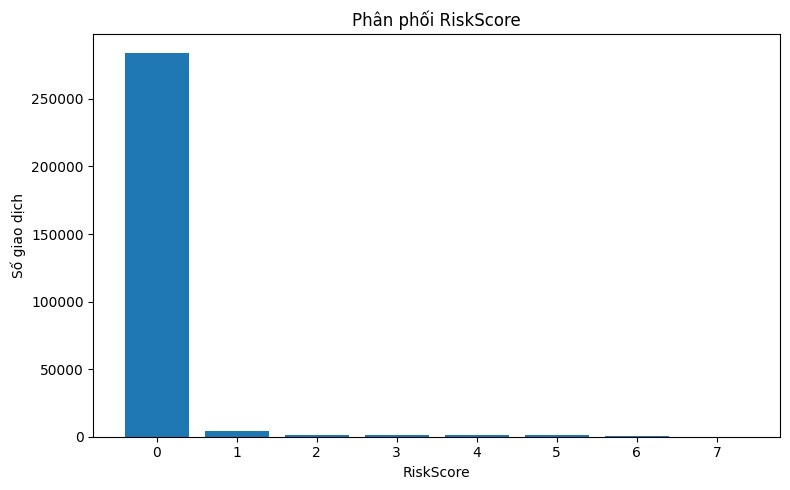

,threshold,count,rate_pct
0,RiskScore >= 1,10618,3.6044
1,RiskScore >= 2,6124,2.0788
2,RiskScore >= 3,4507,1.5299
3,RiskScore >= 4,3492,1.1854
4,RiskScore >= 5,2039,0.6922
5,RiskScore >= 6,841,0.2855
6,RiskScore >= 7,139,0.0472


,stage,condition,count,rate_vs_total_pct
0,Tổng giao dịch,All,294588,100.0000
1,Cần theo dõi,RiskScore >= 2,6124,2.0788
2,Nghi ngờ cao,RiskScore >= 3,4507,1.5299


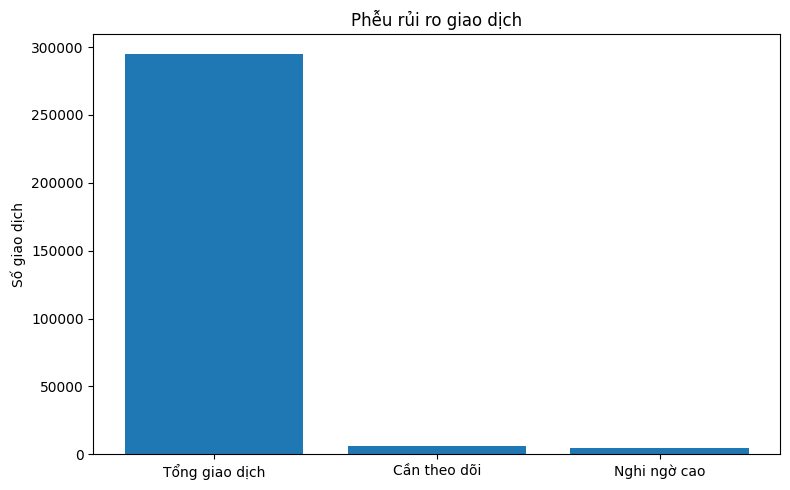

,rule,activated_in_potential_fraud,pct_in_potential_fraud,activated_total,activated_total_pct
2,rule_card_history_outlier,4488,99.5784,6026,2.0456
0,rule_global_extreme_amount,2947,65.3872,2947,1.0004
1,rule_amount_to_limit_high,2720,60.3506,2946,1.0000
5,rule_night_high_amount,1454,32.2609,3728,1.2655
3,rule_daily_cumulative_high,945,20.9674,2946,1.0000
4,rule_rapid_high_amount,43,0.9541,194,0.0659


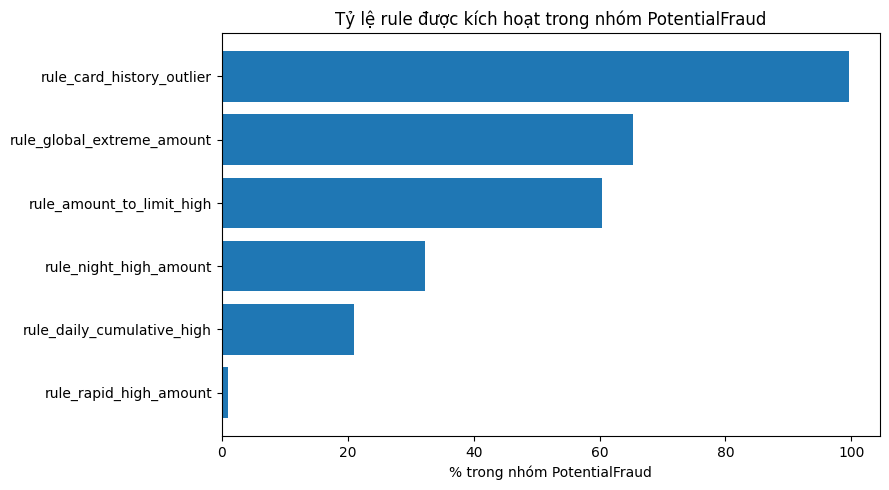

In [16]:
def save_fig(filename):
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

risk_score_distribution = df["RiskScore"].value_counts().sort_index().reset_index()
risk_score_distribution.columns = ["RiskScore", "transaction_count"]
risk_score_distribution["rate_pct"] = risk_score_distribution["transaction_count"] / len(df) * 100

display(risk_score_distribution)
risk_score_distribution.to_csv(DASHBOARD_DIR / "risk_score_distribution.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(8, 5))
plt.bar(risk_score_distribution["RiskScore"], risk_score_distribution["transaction_count"])
plt.title("Phân phối RiskScore")
plt.xlabel("RiskScore")
plt.ylabel("Số giao dịch")
save_fig("risk_score_distribution.png")

threshold_rows = []
for t in range(1, int(df["RiskScore"].max()) + 1):
    count = int((df["RiskScore"] >= t).sum())
    threshold_rows.append({
        "threshold": f"RiskScore >= {t}",
        "count": count,
        "rate_pct": count / len(df) * 100
    })

risk_threshold_sensitivity = pd.DataFrame(threshold_rows)
display(risk_threshold_sensitivity)
risk_threshold_sensitivity.to_csv(DASHBOARD_DIR / "risk_threshold_sensitivity.csv", index=False, encoding="utf-8-sig")

risk_funnel = pd.DataFrame({
    "stage": ["Tổng giao dịch", "Cần theo dõi", "Nghi ngờ cao"],
    "condition": ["All", "RiskScore >= 2", "RiskScore >= 3"],
    "count": [len(df), int(df["NeedReview"].sum()), int(df["PotentialFraud"].sum())]
})
risk_funnel["rate_vs_total_pct"] = risk_funnel["count"] / len(df) * 100

display(risk_funnel)
risk_funnel.to_csv(DASHBOARD_DIR / "risk_funnel.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(8, 5))
plt.bar(risk_funnel["stage"], risk_funnel["count"])
plt.title("Phễu rủi ro giao dịch")
plt.ylabel("Số giao dịch")
save_fig("risk_funnel.png")

high_risk_df = df[df["PotentialFraud"] == 1]
rule_contribution = pd.DataFrame({
    "rule": rule_cols,
    "activated_in_potential_fraud": [int(high_risk_df[c].sum()) for c in rule_cols],
    "pct_in_potential_fraud": [high_risk_df[c].mean() * 100 if len(high_risk_df) else 0 for c in rule_cols],
    "activated_total": [int(df[c].sum()) for c in rule_cols],
    "activated_total_pct": [df[c].mean() * 100 for c in rule_cols],
}).sort_values("pct_in_potential_fraud", ascending=False)

display(rule_contribution)
rule_contribution.to_csv(DASHBOARD_DIR / "risk_rule_contribution.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(9, 5))
plt.barh(rule_contribution["rule"], rule_contribution["pct_in_potential_fraud"])
plt.title("Tỷ lệ rule được kích hoạt trong nhóm PotentialFraud")
plt.xlabel("% trong nhóm PotentialFraud")
plt.gca().invert_yaxis()
save_fig("risk_rule_contribution.png")

## Nhận xét RiskScore

RiskScore bản điều chỉnh có 3 điểm cần nhấn mạnh:

1. Nhóm không dùng ngưỡng cứng một cách máy móc.
2. Ngưỡng hạn mức được điều chỉnh theo phân phối dữ liệu vì giao dịch chạm/vượt hạn mức rất hiếm.
3. `PotentialFraud` vẫn là nhãn proxy, không phải fraud thật.

Nếu rule số tiền hoặc lịch sử thẻ vẫn chi phối mạnh, đây là hạn chế cần nêu trong slide.

# 10. EDA sau RiskScore

Sau khi có `NeedReview` và `PotentialFraud`, phân tích tỷ lệ rủi ro theo:

- Giờ giao dịch.
- Khung giờ.
- Nhóm hạn mức.
- Nhóm khoảng cách địa lý.
- Tiểu bang.

Phần này giúp xem ngoài số tiền còn chiều nào có liên hệ với nhãn nghi ngờ.

,hour,transaction_count,positive_count,positive_rate,positive_rate_pct
0,0,20040,398,0.0199,1.9860
1,1,12802,251,0.0196,1.9606
2,2,7556,153,0.0202,2.0249
3,3,3810,66,0.0173,1.7323
4,4,1823,33,0.0181,1.8102


,time_group,transaction_count,positive_count,positive_rate,positive_rate_pct
0,Afternoon,26593,369,0.0139,1.3876
1,Evening,192635,2669,0.0139,1.3855
2,Morning,1522,26,0.0171,1.7083
3,Night,73838,1443,0.0195,1.9543


,limit_group,transaction_count,positive_count,positive_rate,positive_rate_pct
0,High,80210,1006,0.0125,1.2542
1,Low,106158,1930,0.0182,1.8180
2,Medium,57800,910,0.0157,1.5744
3,Very High,50420,661,0.0131,1.3110


,distance_group,transaction_count,positive_count,positive_rate,positive_rate_pct
0,Far,73647,1100,0.0149,1.4936
1,Medium,73647,1083,0.0147,1.4705
2,Near,73647,1202,0.0163,1.6321
3,Very Far,73647,1122,0.0152,1.5235


,state_full_name,transaction_count,positive_count,positive_rate,positive_rate_pct
8,Idaho,858,18,0.0210,2.0979
18,Missouri,2925,60,0.0205,2.0513
7,Hawaii,839,16,0.0191,1.9070
12,Kansas,53,1,0.0189,1.8868
15,Maryland,796,14,0.0176,1.7588
25,Oklahoma,2284,40,0.0175,1.7513
5,Florida,1612,28,0.0174,1.7370
28,Rhode Island,1253,21,0.0168,1.6760
21,New Mexico,2176,36,0.0165,1.6544
1,Arizona,619,10,0.0162,1.6155


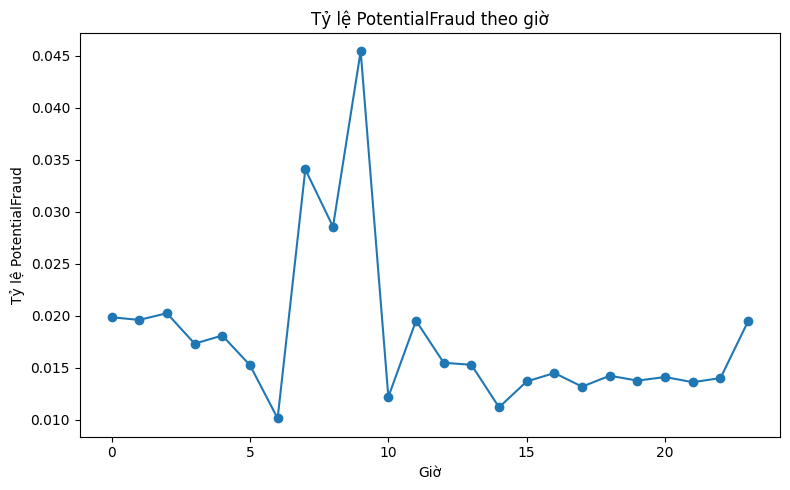

In [17]:
def summarize_rate(data, group_col, target_col):
    out = data.groupby(group_col).agg(
        transaction_count=(target_col, "size"),
        positive_count=(target_col, "sum"),
        positive_rate=(target_col, "mean")
    ).reset_index()
    out["positive_rate_pct"] = out["positive_rate"] * 100
    return out

fraud_by_hour = summarize_rate(df, "hour", "PotentialFraud")
fraud_by_time_group = summarize_rate(df, "time_group", "PotentialFraud")
fraud_by_limit_group = summarize_rate(df, "limit_group", "PotentialFraud")
fraud_by_distance_group = summarize_rate(df, "distance_group", "PotentialFraud")
fraud_by_state = summarize_rate(df, "state_full_name", "PotentialFraud").sort_values(
    ["positive_rate", "transaction_count"], ascending=False
)

display(fraud_by_hour.head())
display(fraud_by_time_group)
display(fraud_by_limit_group)
display(fraud_by_distance_group)
display(fraud_by_state.head(15))

fraud_by_hour.to_csv(DASHBOARD_DIR / "potential_fraud_by_hour.csv", index=False, encoding="utf-8-sig")
fraud_by_time_group.to_csv(DASHBOARD_DIR / "potential_fraud_by_time_group.csv", index=False, encoding="utf-8-sig")
fraud_by_limit_group.to_csv(DASHBOARD_DIR / "potential_fraud_by_limit_group.csv", index=False, encoding="utf-8-sig")
fraud_by_distance_group.to_csv(DASHBOARD_DIR / "potential_fraud_by_distance_group.csv", index=False, encoding="utf-8-sig")
fraud_by_state.to_csv(DASHBOARD_DIR / "potential_fraud_by_state.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(8, 5))
plt.plot(fraud_by_hour["hour"], fraud_by_hour["positive_rate"], marker="o")
plt.title("Tỷ lệ PotentialFraud theo giờ")
plt.xlabel("Giờ")
plt.ylabel("Tỷ lệ PotentialFraud")
save_fig("potential_fraud_rate_by_hour.png")

## Nhận xét EDA sau RiskScore

Phần này là cầu nối sang ANOVA và Chi-square.

Cần chú ý:

- Nếu `time_group` có tỷ lệ nghi ngờ khác nhau, Chi-square sẽ kiểm tra chính thức.
- Nếu `limit_group` có tỷ lệ nghi ngờ khác nhau, Chi-square kiểm tra chính thức.
- Nếu `distance_group` yếu, vẫn có giá trị vì cho thấy yếu tố địa lý chỉ là bổ trợ, không phải tín hiệu chính.

# 11. ANOVA

Notebook dùng 3 câu hỏi ANOVA, không chạy tràn lan:

1. `transaction_dollar_amount ~ limit_group`  
   Số tiền giao dịch có khác biệt giữa các nhóm hạn mức không?

2. `distance_from_card_center_km ~ PotentialFraud`  
   Giao dịch nghi ngờ cao có xu hướng xa vùng giao dịch quen thuộc hơn không?

3. `minutes_since_prev_txn_capped ~ PotentialFraud`  
   Giao dịch nghi ngờ cao có xu hướng xuất hiện gần giao dịch trước hơn không?

Với cỡ mẫu lớn, p-value dễ nhỏ nên phải đọc thêm `eta_squared`.

In [18]:
def eta_squared_oneway(data, value_col, group_col):
    temp = data[[value_col, group_col]].dropna()
    grand_mean = temp[value_col].mean()
    ss_total = ((temp[value_col] - grand_mean) ** 2).sum()
    ss_between = 0

    for _, group in temp.groupby(group_col):
        ss_between += len(group) * (group[value_col].mean() - grand_mean) ** 2

    return ss_between / ss_total if ss_total > 0 else np.nan

def interpret_eta_squared(eta):
    if pd.isna(eta):
        return "Không xác định"
    if eta < 0.01:
        return "Rất yếu"
    elif eta < 0.06:
        return "Yếu"
    elif eta < 0.14:
        return "Trung bình"
    return "Mạnh"

def run_anova(data, value_col, group_col, question, run_tukey=True):
    temp = data[[value_col, group_col]].dropna().copy()
    groups = [g[value_col].values for _, g in temp.groupby(group_col)]
    group_names = [str(name) for name, _ in temp.groupby(group_col)]

    lev_stat, lev_p = levene(*groups) if len(groups) >= 2 else (np.nan, np.nan)
    f_stat, p_value = f_oneway(*groups) if len(groups) >= 2 else (np.nan, np.nan)
    eta = eta_squared_oneway(temp, value_col, group_col)

    result = {
        "question": question,
        "value_col": value_col,
        "group_col": group_col,
        "n_groups": len(groups),
        "groups": ", ".join(group_names),
        "levene_stat": lev_stat,
        "levene_p_value": lev_p,
        "anova_f_statistic": f_stat,
        "anova_p_value": p_value,
        "eta_squared": eta,
        "effect_size_strength": interpret_eta_squared(eta),
        "variance_assumption": "Không đồng nhất" if lev_p < 0.05 else "Có thể xem là đồng nhất",
    }

    if p_value < 0.05:
        result["interpretation"] = (
            f"Có khác biệt thống kê giữa các nhóm của {group_col}; "
            f"effect size: {interpret_eta_squared(eta)}."
        )
    else:
        result["interpretation"] = f"Chưa có bằng chứng khác biệt rõ ràng giữa các nhóm của {group_col}."

    tukey_df = None
    if run_tukey and len(groups) >= 3:
        tukey = pairwise_tukeyhsd(
            endog=temp[value_col],
            groups=temp[group_col].astype(str),
            alpha=0.05
        )
        tukey_df = pd.DataFrame(tukey.summary().data[1:], columns=tukey.summary().data[0])
        tukey_df["value_col"] = value_col
        tukey_df["group_col"] = group_col

    return result, tukey_df

In [19]:
anova_specs = [
    {
        "value_col": "transaction_dollar_amount",
        "group_col": "limit_group",
        "question": "Số tiền giao dịch trung bình có khác biệt giữa các nhóm hạn mức thẻ không?"
    },
    {
        "value_col": "distance_from_card_center_km",
        "group_col": "PotentialFraud",
        "question": "Giao dịch nghi ngờ cao có xu hướng xảy ra xa vùng giao dịch quen thuộc hơn không?"
    },
    {
        "value_col": "minutes_since_prev_txn_capped",
        "group_col": "PotentialFraud",
        "question": "Giao dịch nghi ngờ cao có xu hướng xuất hiện gần giao dịch trước hơn không?"
    }
]

anova_results = []
tukey_results = []

for spec in anova_specs:
    print("\n" + "=" * 100)
    print(spec["question"])
    res, tukey_df = run_anova(df, **spec)
    anova_results.append(res)
    display(pd.DataFrame([res]))

    if tukey_df is not None:
        print("Tukey HSD:")
        display(tukey_df.head(20))
        tukey_results.append(tukey_df)

anova_results_df = pd.DataFrame(anova_results)
display(anova_results_df)
anova_results_df.to_csv(DASHBOARD_DIR / "anova_results.csv", index=False, encoding="utf-8-sig")

if tukey_results:
    tukey_results_df = pd.concat(tukey_results, ignore_index=True)
else:
    tukey_results_df = pd.DataFrame()

tukey_results_df.to_csv(DASHBOARD_DIR / "anova_tukey_results.csv", index=False, encoding="utf-8-sig")


Số tiền giao dịch trung bình có khác biệt giữa các nhóm hạn mức thẻ không?


,question,value_col,group_col,n_groups,groups,levene_stat,levene_p_value,anova_f_statistic,anova_p_value,eta_squared,effect_size_strength,variance_assumption,interpretation
0,Số tiền giao dịch trung bình có khác biệt giữa...,transaction_dollar_amount,limit_group,4,"High, Low, Medium, Very High",507.3898,0.0000,"3,252.3898",0.0000,0.0321,Yếu,Không đồng nhất,Có khác biệt thống kê giữa các nhóm của limit_...


Tukey HSD:


,group1,group2,meandiff,p-adj,lower,upper,reject,value_col,group_col
0,High,Low,-27.0230,0.0000,-28.4970,-25.5489,True,transaction_dollar_amount,limit_group
1,High,Medium,-11.7126,0.0000,-13.4317,-9.9936,True,transaction_dollar_amount,limit_group
2,High,Very High,37.4315,0.0000,35.6408,39.2221,True,transaction_dollar_amount,limit_group
3,Low,Medium,15.3103,0.0000,13.6817,16.9390,True,transaction_dollar_amount,limit_group
4,Low,Very High,64.4544,0.0000,62.7503,66.1585,True,transaction_dollar_amount,limit_group
5,Medium,Very High,49.1441,0.0000,47.2241,51.0641,True,transaction_dollar_amount,limit_group



Giao dịch nghi ngờ cao có xu hướng xảy ra xa vùng giao dịch quen thuộc hơn không?


,question,value_col,group_col,n_groups,groups,levene_stat,levene_p_value,anova_f_statistic,anova_p_value,eta_squared,effect_size_strength,variance_assumption,interpretation
0,Giao dịch nghi ngờ cao có xu hướng xảy ra xa v...,distance_from_card_center_km,PotentialFraud,2,"0, 1",0.3576,0.5498,0.1592,0.6899,0.0000,Rất yếu,Có thể xem là đồng nhất,Chưa có bằng chứng khác biệt rõ ràng giữa các ...



Giao dịch nghi ngờ cao có xu hướng xuất hiện gần giao dịch trước hơn không?


,question,value_col,group_col,n_groups,groups,levene_stat,levene_p_value,anova_f_statistic,anova_p_value,eta_squared,effect_size_strength,variance_assumption,interpretation
0,Giao dịch nghi ngờ cao có xu hướng xuất hiện g...,minutes_since_prev_txn_capped,PotentialFraud,2,"0, 1",0.6573,0.4175,1.0977,0.2948,0.0000,Rất yếu,Có thể xem là đồng nhất,Chưa có bằng chứng khác biệt rõ ràng giữa các ...


,question,value_col,group_col,n_groups,groups,levene_stat,levene_p_value,anova_f_statistic,anova_p_value,eta_squared,effect_size_strength,variance_assumption,interpretation
0,Số tiền giao dịch trung bình có khác biệt giữa...,transaction_dollar_amount,limit_group,4,"High, Low, Medium, Very High",507.3898,0.0000,"3,252.3898",0.0000,0.0321,Yếu,Không đồng nhất,Có khác biệt thống kê giữa các nhóm của limit_...
1,Giao dịch nghi ngờ cao có xu hướng xảy ra xa v...,distance_from_card_center_km,PotentialFraud,2,"0, 1",0.3576,0.5498,0.1592,0.6899,0.0000,Rất yếu,Có thể xem là đồng nhất,Chưa có bằng chứng khác biệt rõ ràng giữa các ...
2,Giao dịch nghi ngờ cao có xu hướng xuất hiện g...,minutes_since_prev_txn_capped,PotentialFraud,2,"0, 1",0.6573,0.4175,1.0977,0.2948,0.0000,Rất yếu,Có thể xem là đồng nhất,Chưa có bằng chứng khác biệt rõ ràng giữa các ...


## Nhận xét ANOVA

Khi bảo vệ, không nên nói “p-value nhỏ là có ý nghĩa mạnh”.

Cách diễn giải đúng:

- ANOVA 1 kiểm tra amount theo nhóm hạn mức.
- ANOVA 2 kiểm tra yếu tố địa lý.
- ANOVA 3 kiểm tra yếu tố tần suất/giao dịch liên tiếp.
- Nếu `eta_squared` nhỏ, nghĩa là khác biệt có thể có ý nghĩa thống kê nhưng tác động thực tiễn yếu.

Đây là điểm giúp bài có chiều sâu hơn bản cũ.

# 12. Chi-square

Notebook dùng 3 câu hỏi Chi-square:

1. `time_group × PotentialFraud`
2. `limit_group × PotentialFraud`
3. `distance_group × PotentialFraud`

Cần đọc:

- `p_value`
- `min_expected_frequency`
- `Cramér's V`

Nếu `Cramér's V` rất thấp, phải nói thẳng là liên hệ thực tiễn yếu.

In [20]:
def cramers_v(chi2, n, r, c):
    denom = n * min(r - 1, c - 1)
    return np.sqrt(chi2 / denom) if denom > 0 else np.nan

def interpret_cramers_v(v):
    if pd.isna(v):
        return "Không xác định"
    if v < 0.10:
        return "Yếu"
    elif v < 0.30:
        return "Trung bình"
    return "Mạnh"

def run_chi_square(data, row_col, col_col, question):
    temp = data[[row_col, col_col]].dropna()
    contingency = pd.crosstab(temp[row_col], temp[col_col])
    chi2, p_value, dof, expected = chi2_contingency(contingency)

    expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
    n = contingency.values.sum()
    r, c = contingency.shape
    v = cramers_v(chi2, n, r, c)
    min_expected = expected_df.min().min()
    is_valid = min_expected >= 5

    result = {
        "question": question,
        "row_col": row_col,
        "col_col": col_col,
        "chi2_statistic": chi2,
        "p_value": p_value,
        "dof": dof,
        "cramers_v": v,
        "effect_size_strength": interpret_cramers_v(v),
        "min_expected_frequency": min_expected,
        "is_valid": is_valid,
    }

    if not is_valid:
        result["interpretation"] = "Không dùng làm kết luận chính vì vi phạm expected frequency >= 5."
    elif p_value < 0.05:
        result["interpretation"] = (
            f"Có liên hệ thống kê; mức liên hệ thực tiễn: {interpret_cramers_v(v)}."
        )
    else:
        result["interpretation"] = "Chưa có bằng chứng liên hệ thống kê rõ ràng."

    return result, contingency, expected_df

In [21]:
chi_specs = [
    {
        "row_col": "time_group",
        "col_col": "PotentialFraud",
        "question": "Giao dịch nghi ngờ cao có liên hệ với khung giờ giao dịch không?"
    },
    {
        "row_col": "limit_group",
        "col_col": "PotentialFraud",
        "question": "Giao dịch nghi ngờ cao có liên hệ với nhóm hạn mức không?"
    },
    {
        "row_col": "distance_group",
        "col_col": "PotentialFraud",
        "question": "Giao dịch nghi ngờ cao có liên hệ với nhóm khoảng cách địa lý không?"
    }
]

chi_results = []
contingency_tables = {}

for spec in chi_specs:
    print("\n" + "=" * 100)
    print(spec["question"])
    res, contingency, expected_df = run_chi_square(df, **spec)
    chi_results.append(res)
    contingency_tables[f"{spec['row_col']}_x_{spec['col_col']}"] = contingency

    print("Contingency table:")
    display(contingency)
    print("Expected frequency:")
    display(expected_df)
    display(pd.DataFrame([res]))

chi_results_df = pd.DataFrame(chi_results)
display(chi_results_df)
chi_results_df.to_csv(DASHBOARD_DIR / "chi_square_results.csv", index=False, encoding="utf-8-sig")

for name, table in contingency_tables.items():
    table.to_csv(DASHBOARD_DIR / f"contingency_{name}.csv", encoding="utf-8-sig")


Giao dịch nghi ngờ cao có liên hệ với khung giờ giao dịch không?
Contingency table:


PotentialFraud,0,1
time_group,,
Afternoon,26224,369
Evening,189966,2669
Morning,1496,26
Night,72395,1443


Expected frequency:


PotentialFraud,0,1
time_group,,
Afternoon,"26,186.1448",406.8552
Evening,"189,687.8129","2,947.1871"
Morning,"1,498.7144",23.2856
Night,"72,708.3278","1,129.6722"


,question,row_col,col_col,chi2_statistic,p_value,dof,cramers_v,effect_size_strength,min_expected_frequency,is_valid,interpretation
0,Giao dịch nghi ngờ cao có liên hệ với khung gi...,time_group,PotentialFraud,118.8199,0.0000,3,0.0201,Yếu,23.2856,True,Có liên hệ thống kê; mức liên hệ thực tiễn: Yếu.


...

PotentialFraud,0,1
distance_group,,
Far,72547,1100
Medium,72564,1083
Near,72445,1202
Very Far,72525,1122


Expected frequency:


PotentialFraud,0,1
distance_group,,
Far,"72,520.2500","1,126.7500"
Medium,"72,520.2500","1,126.7500"
Near,"72,520.2500","1,126.7500"
Very Far,"72,520.2500","1,126.7500"


,question,row_col,col_col,chi2_statistic,p_value,dof,cramers_v,effect_size_strength,min_expected_frequency,is_valid,interpretation
0,Giao dịch nghi ngờ cao có liên hệ với nhóm kho...,distance_group,PotentialFraud,7.4941,0.0577,3,0.0050,Yếu,"1,126.7500",True,Chưa có bằng chứng liên hệ thống kê rõ ràng.


,question,row_col,col_col,chi2_statistic,p_value,dof,cramers_v,effect_size_strength,min_expected_frequency,is_valid,interpretation
0,Giao dịch nghi ngờ cao có liên hệ với khung gi...,time_group,PotentialFraud,118.8199,0.0000,3,0.0201,Yếu,23.2856,True,Có liên hệ thống kê; mức liên hệ thực tiễn: Yếu.
1,Giao dịch nghi ngờ cao có liên hệ với nhóm hạn...,limit_group,PotentialFraud,115.7708,0.0000,3,0.0198,Yếu,771.3924,True,Có liên hệ thống kê; mức liên hệ thực tiễn: Yếu.
2,Giao dịch nghi ngờ cao có liên hệ với nhóm kho...,distance_group,PotentialFraud,7.4941,0.0577,3,0.0050,Yếu,"1,126.7500",True,Chưa có bằng chứng liên hệ thống kê rõ ràng.


## Nhận xét Chi-square

Cách bảo vệ câu hỏi `distance_group × PotentialFraud` nếu Cramér's V rất thấp:

> Nhóm đã kiểm tra giả thuyết địa lý, nhưng kết quả cho thấy khoảng cách địa lý gần như không có liên hệ thực tiễn đáng kể với nhãn proxy. Vì vậy, yếu tố địa lý chỉ được giữ ở vai trò mô tả/dashboard, không đưa vào lõi RiskScore hay kết luận chính.

Đây không phải lỗi. Một kết quả yếu vẫn có giá trị vì nó giúp loại bỏ giả thuyết không đủ mạnh.

# 13. Linear Regression

Linear Regression không dùng để phát hiện gian lận.

Mục tiêu:

> Kiểm tra các biến hiện có giải thích được bao nhiêu biến động của số tiền giao dịch.

Target:

```text
log1p(transaction_dollar_amount)
```

Dùng log vì số tiền giao dịch thường lệch phải.

,model,mae_log,rmse_log,r2_log_scale,mae_usd_original_scale,rmse_usd_original_scale
0,DummyRegressor,0.7334,0.9607,-0.0000,55.1831,127.0478
1,LinearRegression,0.6612,0.8967,0.1289,50.6479,123.9199


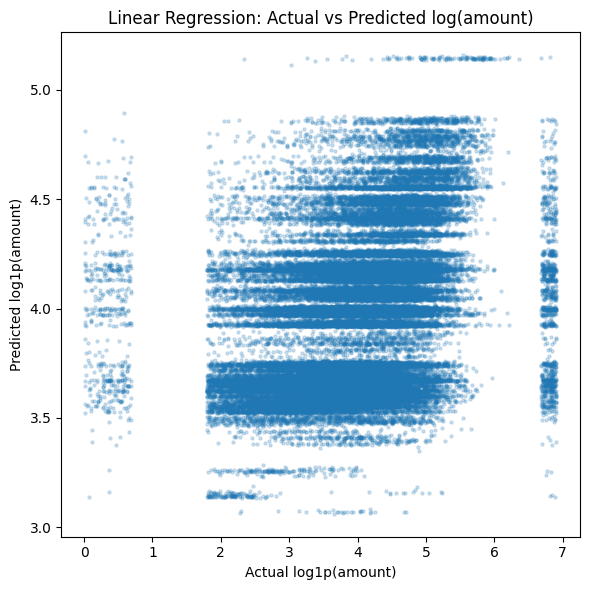

In [22]:
df["log_amount"] = np.log1p(df["transaction_dollar_amount"])

reg_num = [
    "credit_card_limit", "hour", "dayofweek", "month_num",
    "is_weekend", "is_night", "Lat", "Long"
]
reg_cat = ["time_group", "limit_group", "state"]

reg_num = [c for c in reg_num if c in df.columns]
reg_cat = [c for c in reg_cat if c in df.columns]

X_reg = df[reg_num + reg_cat].copy()
y_reg = df["log_amount"].copy()

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

preprocess_reg = ColumnTransformer([
    ("num", StandardScaler(), reg_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), reg_cat)
])

dummy_reg = DummyRegressor(strategy="mean")
linear_reg = Pipeline([
    ("preprocess", preprocess_reg),
    ("model", LinearRegression())
])

dummy_reg.fit(X_train_reg, y_train_reg)
linear_reg.fit(X_train_reg, y_train_reg)

pred_dummy_log = dummy_reg.predict(X_test_reg)
pred_linear_log = linear_reg.predict(X_test_reg)

def regression_metrics(y_true_log, y_pred_log, model_name):
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    r2 = r2_score(y_true_log, y_pred_log)

    y_true_usd = np.expm1(y_true_log)
    y_pred_usd = np.maximum(np.expm1(y_pred_log), 0)

    return {
        "model": model_name,
        "mae_log": mae_log,
        "rmse_log": rmse_log,
        "r2_log_scale": r2,
        "mae_usd_original_scale": mean_absolute_error(y_true_usd, y_pred_usd),
        "rmse_usd_original_scale": np.sqrt(mean_squared_error(y_true_usd, y_pred_usd)),
    }

linear_metrics = pd.DataFrame([
    regression_metrics(y_test_reg, pred_dummy_log, "DummyRegressor"),
    regression_metrics(y_test_reg, pred_linear_log, "LinearRegression")
])

display(linear_metrics)
linear_metrics.to_csv(DASHBOARD_DIR / "linear_regression_metrics.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, pred_linear_log, s=5, alpha=0.2)
plt.title("Linear Regression: Actual vs Predicted log(amount)")
plt.xlabel("Actual log1p(amount)")
plt.ylabel("Predicted log1p(amount)")
save_fig("linear_actual_vs_predicted.png")

## Nhận xét Linear Regression

Nếu R² thấp, đây không phải lỗi lớn.

Lý do:

- Số tiền giao dịch phụ thuộc vào loại hàng hóa, merchant, mục đích chi tiêu, thu nhập, bối cảnh mua sắm.
- Dataset hiện tại không có các biến đó.
- Vì vậy, Linear Regression đóng vai trò baseline giải thích, không phải mô hình dự đoán hoàn hảo.

# 14. Feature Audit cho Classification

Do `PotentialFraud` được tạo từ `RiskScore`, cần loại các biến trực tiếp/gián tiếp tạo nhãn khỏi mô hình phân loại.

Điều này giúp giảm circular reasoning.

In [23]:
excluded_features = [
    "RiskScore", "RiskLevel", "NeedReview", "PotentialFraud",
    *rule_cols,
    "amount_zscore_prev", "amount_to_limit", "daily_cum_to_limit",
    "daily_cum_amount", "daily_txn_count", "minutes_since_prev_txn",
    "minutes_since_prev_txn_capped", "prev_txn_count",
    "prev_amount_mean", "prev_amount_std",
    "distance_from_card_center_km"  # dùng EDA/dashboard, không đưa vào model chính
]

feature_audit = pd.DataFrame({
    "excluded_feature": excluded_features,
    "reason": "Trực tiếp/gián tiếp tạo RiskScore hoặc có nguy cơ circular reasoning/leakage"
})

display(feature_audit)
feature_audit.to_csv(DASHBOARD_DIR / "classification_feature_audit_excluded.csv", index=False, encoding="utf-8-sig")

clf_num = [
    "transaction_dollar_amount", "credit_card_limit", "hour", "dayofweek",
    "month_num", "is_weekend", "is_night", "Lat", "Long"
]
clf_cat = ["state", "time_group", "limit_group", "distance_group"]

clf_num = [c for c in clf_num if c in df.columns]
clf_cat = [c for c in clf_cat if c in df.columns]

classification_feature_set = pd.DataFrame({
    "feature": clf_num + clf_cat,
    "type": ["numeric"] * len(clf_num) + ["categorical"] * len(clf_cat)
})

display(classification_feature_set)
classification_feature_set.to_csv(DASHBOARD_DIR / "classification_feature_set.csv", index=False, encoding="utf-8-sig")

,excluded_feature,reason
0,RiskScore,Trực tiếp/gián tiếp tạo RiskScore hoặc có nguy...
1,RiskLevel,Trực tiếp/gián tiếp tạo RiskScore hoặc có nguy...
2,NeedReview,Trực tiếp/gián tiếp tạo RiskScore hoặc có nguy...
3,PotentialFraud,Trực tiếp/gián tiếp tạo RiskScore hoặc có nguy...
4,rule_global_extreme_amount,Trực tiếp/gián tiếp tạo RiskScore hoặc có nguy...
5,rule_amount_to_limit_high,Trực tiếp/gián tiếp tạo RiskScore hoặc có nguy...
6,rule_card_history_outlier,Trực tiếp/gián tiếp tạo RiskScore hoặc có nguy...
7,rule_daily_cumulative_high,Trực tiếp/gián tiếp tạo RiskScore hoặc có nguy...
8,rule_rapid_high_amount,Trực tiếp/gián tiếp tạo RiskScore hoặc có nguy...
9,rule_night_high_amount,Trực tiếp/gián tiếp tạo RiskScore hoặc có nguy...


,feature,type
0,transaction_dollar_amount,numeric
1,credit_card_limit,numeric
2,hour,numeric
3,dayofweek,numeric
4,month_num,numeric
5,is_weekend,numeric
6,is_night,numeric
7,Lat,numeric
8,Long,numeric
9,state,categorical


## Nhận xét Feature Audit

Điểm cần nói khi bảo vệ:

> Nhóm có tạo nhiều biến để phân tích và xây RiskScore, nhưng không đưa trực tiếp các biến tạo nhãn vào mô hình phân loại. Feature set được giữ theo hướng bảo thủ để giảm nguy cơ mô hình học lại công thức RiskScore.

# 15. Logistic Regression

Logistic Regression dùng để phân loại `PotentialFraud`.

Vì dữ liệu mất cân bằng, không kết luận bằng Accuracy.  
Metric chính:

- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

Trong fraud screening, Recall quan trọng vì bỏ sót giao dịch nghi ngờ cao là rủi ro lớn.

Target distribution:


,count
PotentialFraud,
0,290081
1,4507


,proportion
PotentialFraud,
0,98.4701
1,1.5299


,threshold,accuracy,precision_pos,recall_pos,f1_pos,f2_pos,roc_auc
0,0.1000,0.9881,0.5632,0.9989,0.7203,0.8651,0.9996
1,0.2000,0.9931,0.6886,0.9989,0.8152,0.9163,0.9996
2,0.3000,0.9947,0.7444,0.9989,0.8531,0.9350,0.9996
3,0.4000,0.9956,0.7772,0.9989,0.8742,0.9450,0.9996
4,0.5000,0.9959,0.7900,0.9978,0.8818,0.9479,0.9996
5,0.6000,0.9961,0.7977,0.9978,0.8866,0.9501,0.9996
6,0.7000,0.9963,0.8054,0.9967,0.8909,0.9515,0.9996
7,0.8000,0.9964,0.8119,0.9967,0.8949,0.9533,0.9996
8,0.9000,0.9965,0.8183,0.9945,0.8978,0.9534,0.9996


Chosen threshold: 0.9
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     58017
           1       0.82      0.99      0.90       901

    accuracy                           1.00     58918
   macro avg       0.91      1.00      0.95     58918
weighted avg       1.00      1.00      1.00     58918



,Pred_0,Pred_1
Actual_0,57818,199
Actual_1,5,896


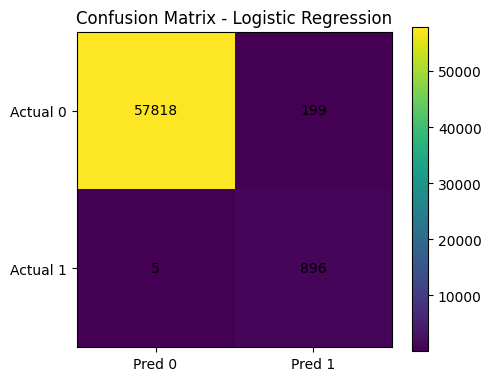

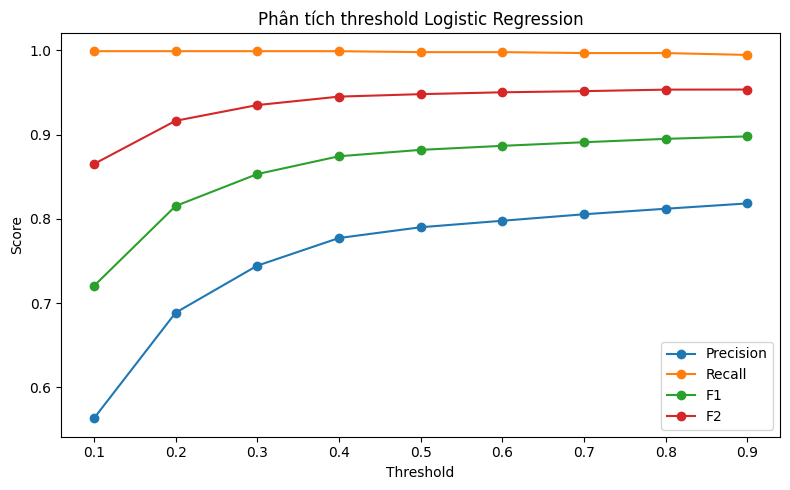

In [24]:
X_clf = df[clf_num + clf_cat].copy()
y_clf = df["PotentialFraud"].copy()

print("Target distribution:")
display(y_clf.value_counts())
display(y_clf.value_counts(normalize=True) * 100)

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

preprocess_clf = ColumnTransformer([
    ("num", StandardScaler(), clf_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), clf_cat)
])

dummy_clf = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)

log_reg = Pipeline([
    ("preprocess", preprocess_clf),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

dummy_clf.fit(X_train, y_train)
log_reg.fit(X_train, y_train)

dummy_pred = dummy_clf.predict(X_test)
log_prob = log_reg.predict_proba(X_test)[:, 1]

threshold_rows = []

for th in np.arange(0.1, 1.0, 0.1):
    pred = (log_prob >= th).astype(int)
    precision = precision_score(y_test, pred, zero_division=0)
    recall = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)

    beta = 2
    f2 = ((1 + beta**2) * precision * recall / ((beta**2 * precision) + recall)) if (precision + recall) > 0 else 0

    threshold_rows.append({
        "threshold": round(float(th), 2),
        "accuracy": accuracy_score(y_test, pred),
        "precision_pos": precision,
        "recall_pos": recall,
        "f1_pos": f1,
        "f2_pos": f2,
        "roc_auc": roc_auc_score(y_test, log_prob)
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)
threshold_df.to_csv(DASHBOARD_DIR / "logistic_threshold_analysis.csv", index=False, encoding="utf-8-sig")

# Chọn threshold theo F2 trước, vì F2 ưu tiên Recall.
chosen_threshold = float(threshold_df.sort_values(["f2_pos", "f1_pos"], ascending=False).iloc[0]["threshold"])
print("Chosen threshold:", chosen_threshold)

log_pred = (log_prob >= chosen_threshold).astype(int)

def cls_metrics(y_true, y_pred, y_prob, model_name, threshold=None):
    return {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_pos": precision_score(y_true, y_pred, zero_division=0),
        "recall_pos": recall_score(y_true, y_pred, zero_division=0),
        "f1_pos": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan
    }

dummy_prob = np.zeros(len(y_test))
metrics_dummy = cls_metrics(y_test, dummy_pred, dummy_prob, "DummyClassifier", None)
metrics_log = cls_metrics(y_test, log_pred, log_prob, "LogisticRegression", chosen_threshold)

print(classification_report(y_test, log_pred, zero_division=0))

cm_log = confusion_matrix(y_test, log_pred)
cm_log_df = pd.DataFrame(cm_log, index=["Actual_0", "Actual_1"], columns=["Pred_0", "Pred_1"])

display(cm_log_df)
cm_log_df.to_csv(DASHBOARD_DIR / "confusion_matrix_logistic.csv", encoding="utf-8-sig")

plt.figure(figsize=(5, 4))
plt.imshow(cm_log)
plt.title("Confusion Matrix - Logistic Regression")
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])
plt.colorbar()

for i in range(cm_log.shape[0]):
    for j in range(cm_log.shape[1]):
        plt.text(j, i, cm_log[i, j], ha="center", va="center")

save_fig("confusion_matrix_logistic.png")

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision_pos"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall_pos"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1_pos"], marker="o", label="F1")
plt.plot(threshold_df["threshold"], threshold_df["f2_pos"], marker="o", label="F2")
plt.title("Phân tích threshold Logistic Regression")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
save_fig("logistic_threshold_analysis.png")

## Nhận xét Logistic Regression

Cần nhấn mạnh:

- DummyClassifier có thể có Accuracy cao nhưng Recall = 0.
- Logistic Regression dùng `class_weight='balanced'` vì dữ liệu mất cân bằng.
- Threshold được chọn theo F2/F1 để ưu tiên Recall.
- Kết quả là học xấp xỉ nhãn proxy, không phải fraud thật.

# 16. Decision Tree

Decision Tree dùng để:

1. Phân loại `PotentialFraud`.
2. Xem feature nào ảnh hưởng nhiều đến dự đoán.

Dùng `max_depth=5` để mô hình dễ giải thích hơn.

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     58017
           1       0.79      1.00      0.88       901

    accuracy                           1.00     58918
   macro avg       0.89      1.00      0.94     58918
weighted avg       1.00      1.00      1.00     58918



,Pred_0,Pred_1
Actual_0,57773,244
Actual_1,0,901


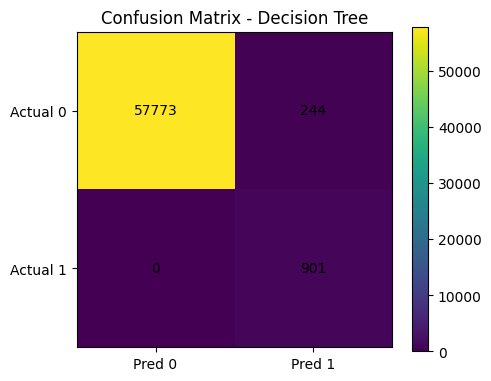

,feature,importance
0,transaction_dollar_amount,0.9879
47,time_group_Night,0.0033
1,credit_card_limit,0.0032
4,month_num,0.0028
6,is_night,0.0019
2,hour,0.0008
5,is_weekend,0.0000
44,time_group_Afternoon,0.0000
8,Long,0.0000
9,state_AL,0.0000


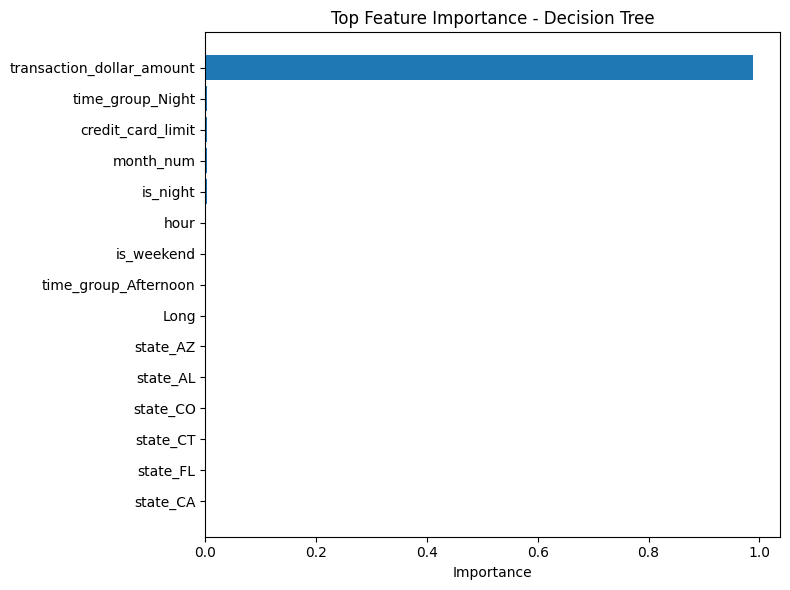

In [25]:
tree_clf = Pipeline([
    ("preprocess", preprocess_clf),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

tree_clf.fit(X_train, y_train)

tree_prob = tree_clf.predict_proba(X_test)[:, 1]
tree_pred = (tree_prob >= 0.5).astype(int)

metrics_tree = cls_metrics(y_test, tree_pred, tree_prob, "DecisionTree_depth5", 0.5)

print(classification_report(y_test, tree_pred, zero_division=0))

cm_tree = confusion_matrix(y_test, tree_pred)
cm_tree_df = pd.DataFrame(cm_tree, index=["Actual_0", "Actual_1"], columns=["Pred_0", "Pred_1"])

display(cm_tree_df)
cm_tree_df.to_csv(DASHBOARD_DIR / "confusion_matrix_decision_tree.csv", encoding="utf-8-sig")

plt.figure(figsize=(5, 4))
plt.imshow(cm_tree)
plt.title("Confusion Matrix - Decision Tree")
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])
plt.colorbar()

for i in range(cm_tree.shape[0]):
    for j in range(cm_tree.shape[1]):
        plt.text(j, i, cm_tree[i, j], ha="center", va="center")

save_fig("confusion_matrix_decision_tree.png")

preprocessor = tree_clf.named_steps["preprocess"]
tree_model = tree_clf.named_steps["model"]

num_names = clf_num
cat_names = list(preprocessor.named_transformers_["cat"].get_feature_names_out(clf_cat))
all_feature_names = num_names + cat_names

feature_importance = pd.DataFrame({
    "feature": all_feature_names,
    "importance": tree_model.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance.head(30))
feature_importance.to_csv(DASHBOARD_DIR / "decision_tree_feature_importance.csv", index=False, encoding="utf-8-sig")

top_fi = feature_importance.head(15).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_fi["feature"], top_fi["importance"])
plt.title("Top Feature Importance - Decision Tree")
plt.xlabel("Importance")
save_fig("decision_tree_feature_importance.png")

## Nhận xét Decision Tree

Nếu `transaction_dollar_amount` vẫn chiếm importance cao, đây là phát hiện cần trình bày thẳng:

> Nhãn proxy vẫn chịu ảnh hưởng lớn từ tín hiệu số tiền. Tuy nhiên, nhóm đã kiểm tra thêm thời gian, hạn mức và địa lý để đánh giá các tín hiệu bổ trợ.

Không nên che điểm này. Nói rõ sẽ làm bài đáng tin hơn.

# 17. So sánh mô hình

So sánh:

- DummyClassifier
- Logistic Regression
- Decision Tree

Mục tiêu là chứng minh mô hình học được nhãn proxy tốt hơn baseline.

In [26]:
classification_comparison = pd.DataFrame([
    metrics_dummy,
    metrics_log,
    metrics_tree
])

display(classification_comparison)
classification_comparison.to_csv(DASHBOARD_DIR / "classification_model_comparison.csv", index=False, encoding="utf-8-sig")

print("Linear Regression metrics:")
display(linear_metrics)

print("Classification comparison:")
display(classification_comparison)

,model,threshold,accuracy,precision_pos,recall_pos,f1_pos,roc_auc
0,DummyClassifier,NaN,0.9847,0.0000,0.0000,0.0000,0.5000
1,LogisticRegression,0.9000,0.9965,0.8183,0.9945,0.8978,0.9996
2,DecisionTree_depth5,0.5000,0.9959,0.7869,1.0000,0.8807,1.0000


Linear Regression metrics:


,model,mae_log,rmse_log,r2_log_scale,mae_usd_original_scale,rmse_usd_original_scale
0,DummyRegressor,0.7334,0.9607,-0.0000,55.1831,127.0478
1,LinearRegression,0.6612,0.8967,0.1289,50.6479,123.9199


Classification comparison:


,model,threshold,accuracy,precision_pos,recall_pos,f1_pos,roc_auc
0,DummyClassifier,NaN,0.9847,0.0000,0.0000,0.0000,0.5000
1,LogisticRegression,0.9000,0.9965,0.8183,0.9945,0.8978,0.9996
2,DecisionTree_depth5,0.5000,0.9959,0.7869,1.0000,0.8807,1.0000


## Nhận xét so sánh mô hình

Cách đọc:

- DummyClassifier dùng để chứng minh Accuracy không đủ trong dữ liệu mất cân bằng.
- Logistic Regression phù hợp nếu cần điều chỉnh threshold và ưu tiên Recall.
- Decision Tree phù hợp nếu cần giải thích feature importance.
- Cả hai mô hình đều học nhãn proxy `PotentialFraud`, không phải fraud thật.

# 18. Xuất file cho Dashboard và Slide

Phần này xuất:

- Dataset đã xử lý.
- KPI.
- RiskScore distribution.
- ANOVA/Chi-square results.
- Model metrics.
- Confusion matrix.
- Feature importance.
- Top giao dịch nghi ngờ.
- Hình PNG.

In [27]:
processed_path = PROCESSED_DIR / "creditcard_processed_final.csv"
df.to_csv(processed_path, index=False, encoding="utf-8-sig")
print("Saved:", processed_path)

kpi_summary = pd.DataFrame({
    "metric": [
        "total_transactions", "total_credit_cards", "total_amount", "average_amount",
        "need_review_transactions", "need_review_rate",
        "potential_fraud_transactions", "potential_fraud_rate"
    ],
    "value": [
        len(df),
        df["credit_card"].nunique(),
        df["transaction_dollar_amount"].sum(),
        df["transaction_dollar_amount"].mean(),
        df["NeedReview"].sum(),
        df["NeedReview"].mean(),
        df["PotentialFraud"].sum(),
        df["PotentialFraud"].mean()
    ]
})

display(kpi_summary)
kpi_summary.to_csv(DASHBOARD_DIR / "dashboard_kpi_summary.csv", index=False, encoding="utf-8-sig")

top_suspicious_transactions = (
    df.sort_values(["RiskScore", "transaction_dollar_amount"], ascending=False)
    [[
        "credit_card", "date", "transaction_dollar_amount", "credit_card_limit",
        "city", "state", "state_full_name", "hour", "time_group",
        "limit_group", "distance_from_card_center_km", "distance_group",
        "RiskScore", "RiskLevel", "NeedReview", "PotentialFraud"
    ]]
    .head(100)
)

display(top_suspicious_transactions.head(20))
top_suspicious_transactions.to_csv(
    DASHBOARD_DIR / "top_suspicious_transactions.csv",
    index=False,
    encoding="utf-8-sig"
)

for col in ["PotentialFraud", "NeedReview", "RiskLevel", "time_group", "limit_group", "distance_group"]:
    out = df[col].value_counts().reset_index()
    out.columns = [col, "count"]
    out["rate_pct"] = out["count"] / len(df) * 100
    out.to_csv(DASHBOARD_DIR / f"distribution_{col}.csv", index=False, encoding="utf-8-sig")

zip_output = Path("creditcard_project_outputs_FINAL_V2.zip")

with zipfile.ZipFile(zip_output, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for folder in [PROCESSED_DIR, DASHBOARD_DIR, FIG_DIR]:
        for file in folder.rglob("*"):
            if file.is_file():
                z.write(file, arcname=str(file))

print("Đã nén outputs:", zip_output.resolve())

Saved: data/processed/creditcard_processed_final.csv


,metric,value
0,total_transactions,"294,588.0000"
1,total_credit_cards,984.0000
2,total_amount,"25,336,935.3600"
3,average_amount,86.0080
4,need_review_transactions,"6,124.0000"
5,need_review_rate,0.0208
6,potential_fraud_transactions,"4,507.0000"
7,potential_fraud_rate,0.0153


,credit_card,date,transaction_dollar_amount,credit_card_limit,city,state,state_full_name,hour,time_group,limit_group,distance_from_card_center_km,distance_group,RiskScore,RiskLevel,NeedReview,PotentialFraud
60778,2980539633198204,2015-08-09 03:37:43,998.4300,7000,Washington,NH,New Hampshire,3,Night,Low,167.5112,Far,7,High,1,1
228618,7802709536607734,2015-10-04 00:15:48,997.5800,16000,Springfield,MA,Massachusetts,0,Night,High,85.4316,Near,7,High,1,1
269516,9262144464078962,2015-08-27 23:03:26,997.3300,12000,Washington,NH,New Hampshire,23,Night,Medium,94.0633,Near,7,High,1,1
76745,3436245968389889,2015-10-03 23:43:28,996.6600,10000,Houston,PA,Pennsylvania,23,Night,Low,121.8800,Medium,7,High,1,1
187617,6521271718368276,2015-09-13 02:14:57,996.3400,7000,Madison,NH,New Hampshire,2,Night,Low,67.3805,Near,7,High,1,1
2786,1126571863414211,2015-09-11 01:33:04,996.1700,8000,Houston,PA,Pennsylvania,1,Night,Low,348.9502,Very Far,7,High,1,1
7867,1210872963953886,2015-09-29 04:28:42,995.8600,7000,Columbus,NJ,New Jersey,4,Night,Low,166.0348,Far,7,High,1,1
73045,3311276221301887,2015-09-05 02:20:52,995.8400,6000,Atlanta,NY,New York,2,Night,Low,119.7267,Medium,7,High,1,1
51819,2610112472096585,2015-08-14 22:05:14,995.2000,12000,Washington,NH,New Hampshire,22,Evening,Medium,216.0317,Very Far,7,High,1,1
80407,3539204020033123,2015-09-25 02:57:06,995.1600,10000,Oklahoma City,OK,Oklahoma,2,Night,Low,217.1423,Very Far,7,High,1,1


Đã nén outputs: /content/creditcard_project_outputs_FINAL_V2.zip


# 19. Kết luận notebook

Các điểm kết luận chính:

1. Dataset không có nhãn gian lận thật, nên nhóm xây dựng nhãn proxy.
2. Feature Engineering khai thác nhiều chiều: thời gian, hạn mức, lịch sử thẻ, địa lý.
3. RiskScore bản điều chỉnh dùng ngưỡng percentile để phù hợp phân phối dataset.
4. ANOVA và Chi-square được dùng có kiểm soát, mỗi phương pháp 3 câu hỏi chính.
5. `distance_group` nếu có Cramér's V rất yếu thì chỉ dùng như tín hiệu mô tả/dashboard.
6. Logistic Regression và Decision Tree học xấp xỉ `PotentialFraud`, không chứng minh fraud thật.
7. Output notebook dùng để làm dashboard và slide.

In [28]:
final_summary = {
    "total_transactions": int(len(df)),
    "total_credit_cards": int(df["credit_card"].nunique()),
    "need_review_count": int(df["NeedReview"].sum()),
    "need_review_rate_pct": float(df["NeedReview"].mean() * 100),
    "potential_fraud_count": int(df["PotentialFraud"].sum()),
    "potential_fraud_rate_pct": float(df["PotentialFraud"].mean() * 100),
    "anova_questions": 3,
    "chi_square_questions": 3,
    "classification_target": "PotentialFraud",
    "important_note": "PotentialFraud là nhãn proxy giao dịch nghi ngờ cao, không phải nhãn gian lận thật."
}

print(json.dumps(final_summary, indent=4, ensure_ascii=False))

with open(OUTPUT_DIR / "final_summary.json", "w", encoding="utf-8") as f:
    json.dump(final_summary, f, indent=4, ensure_ascii=False)

print("Notebook hoàn tất. Kiểm tra thư mục outputs/ để lấy bảng, biểu đồ và dữ liệu cho dashboard/slide.")

{
    "total_transactions": 294588,
    "total_credit_cards": 984,
    "need_review_count": 6124,
    "need_review_rate_pct": 2.0788355262264586,
    "potential_fraud_count": 4507,
    "potential_fraud_rate_pct": 1.5299333306176763,
    "anova_questions": 3,
    "chi_square_questions": 3,
    "classification_target": "PotentialFraud",
    "important_note": "PotentialFraud là nhãn proxy giao dịch nghi ngờ cao, không phải nhãn gian lận thật."
}
Notebook hoàn tất. Kiểm tra thư mục outputs/ để lấy bảng, biểu đồ và dữ liệu cho dashboard/slide.
